In [1]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

from torch_geometric.loader import NeighborLoader
from torch_geometric.utils import (
    to_undirected,
    add_self_loops
)

from sklearn.preprocessing import StandardScaler

# ----- 设置中文字体（解决中文显示问题）-----
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']  # 指定备选字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

c:\Users\26099\.conda\envs\deeplearning\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("显存:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")

Device: cuda
GPU: NVIDIA GeForce RTX 2050
显存: 4.0 GB


In [3]:
dataset = PygNodePropPredDataset(name="ogbn-arxiv")

data = dataset[0]

print(data)

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:06<00:00, 12.85it/s]


Extracting dataset\arxiv.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<?, ?it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<?, ?it/s]

Saving...


Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])


Done!
c:\Users\26099\.conda\envs\deeplearning\lib\site-packages\ogb\nodeproppred\dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices = to

In [4]:
print("节点数：", data.num_nodes)
print("边数：", data.num_edges)

print("特征维度：", data.x.shape[1])
print("类别数：", dataset.num_classes)

节点数： 169343
边数： 1166243
特征维度： 128
类别数： 40


In [5]:
data.edge_index = to_undirected(data.edge_index)

data.edge_index, _ = add_self_loops(data.edge_index)

print(data.edge_index.shape)

torch.Size([2, 2484941])


类别分布（前10类）:
类 0: 565 个节点
类 1: 687 个节点
类 2: 4839 个节点
类 3: 2080 个节点
类 4: 5862 个节点
类 5: 4958 个节点
类 6: 1618 个节点
类 7: 589 个节点
类 8: 6232 个节点
类 9: 2820 个节点


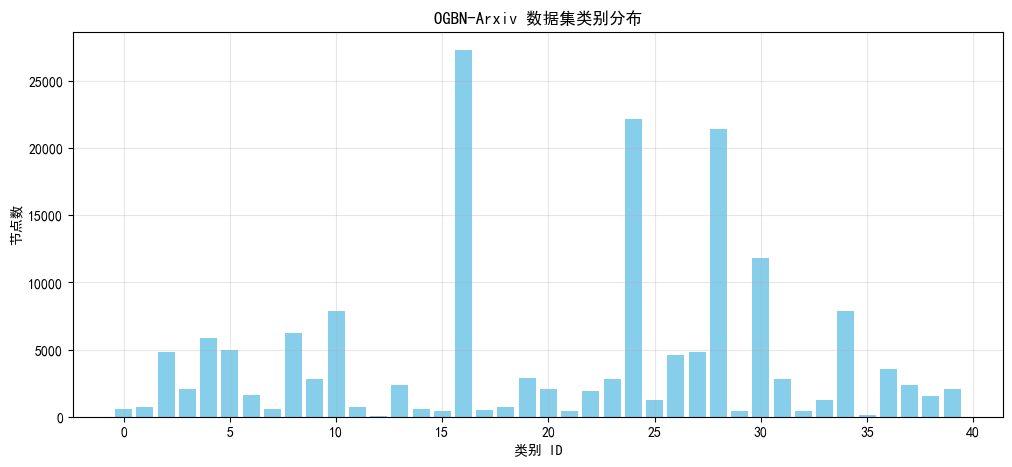

In [63]:
import seaborn as sns

# ===== 1. 类别分布统计与绘图 =====
labels = data.y.view(-1).cpu().numpy()
unique, counts = np.unique(labels, return_counts=True)

# 打印类别分布（前10类）
print("类别分布（前10类）:")
for u, c in zip(unique[:10], counts[:10]):
    print(f"类 {u}: {c} 个节点")

# 绘制类别分布条形图
plt.figure(figsize=(12, 5))
plt.bar(unique, counts, color='skyblue')
plt.xlabel('类别 ID')
plt.ylabel('节点数')
plt.title('OGBN-Arxiv 数据集类别分布')
plt.grid(alpha=0.3)
plt.show()

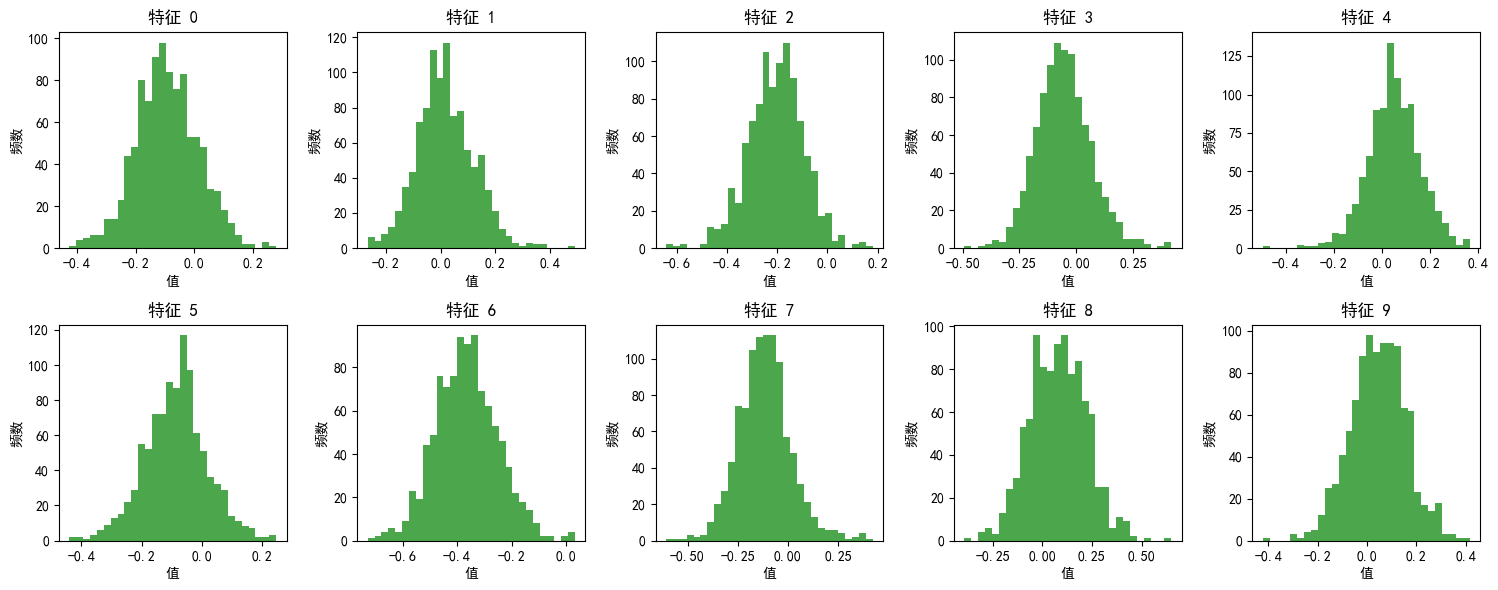

In [61]:
# ===== 2. 特征分布直方图（选取前1000个样本的前10维特征）=====
sample_features = data.x[:1000, :10].cpu().numpy()
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].hist(sample_features[:, i], bins=30, alpha=0.7, color='green')
    axes[i].set_title(f'特征 {i}')
    axes[i].set_xlabel('值')
    axes[i].set_ylabel('频数')
plt.tight_layout()
plt.show()

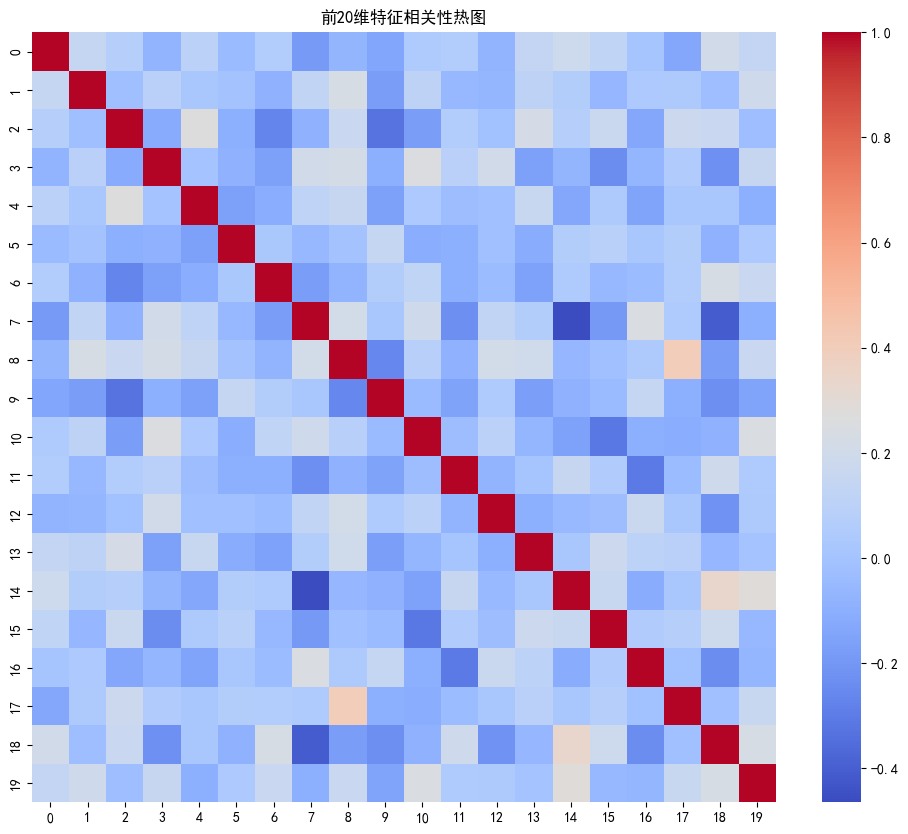

In [62]:
# ===== 3. 特征相关性热图（取前20维）=====
feature_subset = data.x[:, :20].cpu().numpy()
corr_matrix = np.corrcoef(feature_subset.T)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', cbar=True)
plt.title('前20维特征相关性热图')
plt.show()

In [7]:
x = data.x.numpy()

scaler = StandardScaler()

x = scaler.fit_transform(x)

data.x = torch.tensor(
    x,
    dtype=torch.float
)

In [8]:
split_idx = dataset.get_idx_split()

train_idx = split_idx["train"]
valid_idx = split_idx["valid"]
test_idx = split_idx["test"]

print("Train:", len(train_idx))
print("Valid:", len(valid_idx))
print("Test :", len(test_idx))

Train: 90941
Valid: 29799
Test : 48603


In [9]:
data = data.to(device)

train_idx = train_idx.to(device)
valid_idx = valid_idx.to(device)
test_idx = test_idx.to(device)

In [10]:
train_loader = NeighborLoader(
    data,
    input_nodes=train_idx,
    num_neighbors=[25, 20],   # 增加采样范围
    batch_size=1024,
    shuffle=True
)

valid_loader = NeighborLoader(
    data,
    input_nodes=valid_idx,
    num_neighbors=[25, 20],
    batch_size=1024,
    shuffle=False
)

test_loader = NeighborLoader(
    data,
    input_nodes=test_idx,
    num_neighbors=[25, 20],
    batch_size=1024,
    shuffle=False
)

In [11]:
batch = next(iter(train_loader))

print(batch)

print("采样节点数：", batch.num_nodes)
print("采样边数：", batch.num_edges)
print("中心节点数：", batch.batch_size)

Data(num_nodes=46666, edge_index=[2, 106065], x=[46666, 128], node_year=[46666, 1], y=[46666, 1], n_id=[46666], e_id=[106065], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[1024], batch_size=1024)
采样节点数： 46666
采样边数： 106065
中心节点数： 1024


In [12]:
class MLP(nn.Module):
    def __init__(self,
                 in_channels,
                 hidden_channels,
                 out_channels,
                 dropout=0.5):

        super().__init__()

        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)

        self.dropout = dropout

    def forward(self, x, edge_index=None):

        x = self.lin1(x)
        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.lin2(x)

        return x

In [13]:
from torch_geometric.nn import GCNConv


class GCN(nn.Module):

    def __init__(self,
                 in_channels,
                 hidden_channels,
                 out_channels,
                 dropout=0.5):

        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            out_channels
        )

        self.dropout = dropout

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(x, edge_index)

        return x

In [14]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        # 残差连接：如果输入输出维度不同，用线性层投影
        self.res_fc = nn.Linear(in_channels, out_channels) if in_channels != out_channels else nn.Identity()
        self.dropout = dropout

    def forward(self, x, edge_index):
        identity = self.res_fc(x)

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = x + identity          # 残差相加
        return x

In [15]:
from torch_geometric.nn import GATConv


class GAT(nn.Module):

    def __init__(self,
                 in_channels,
                 hidden_channels,
                 out_channels,
                 heads=2,
                 dropout=0.5):

        super().__init__()

        self.conv1 = GATConv(
            in_channels,
            hidden_channels,
            heads=heads,
            dropout=dropout
        )

        self.conv2 = GATConv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            concat=False,
            dropout=dropout
        )

        self.dropout = dropout

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        x = F.elu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(x, edge_index)

        return x

In [16]:
from torch_geometric.nn import APPNP


class APPNPNet(nn.Module):

    def __init__(self,
                 in_channels,
                 hidden_channels,
                 out_channels,
                 K=10,
                 alpha=0.1,
                 dropout=0.5):

        super().__init__()

        self.lin1 = nn.Linear(
            in_channels,
            hidden_channels
        )

        self.lin2 = nn.Linear(
            hidden_channels,
            out_channels
        )

        self.prop = APPNP(
            K=K,
            alpha=alpha
        )

        self.dropout = dropout

    def forward(self, x, edge_index):

        x = self.lin1(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.lin2(x)

        x = self.prop(
            x,
            edge_index
        )

        return x

In [17]:
def build_model(model_name,
                in_channels,
                hidden_channels,
                out_channels):

    if model_name == "mlp":
        return MLP(
            in_channels,
            hidden_channels,
            out_channels
        )

    elif model_name == "gcn":
        return GCN(
            in_channels,
            hidden_channels,
            out_channels
        )

    elif model_name == "sage":
        return GraphSAGE(
            in_channels,
            hidden_channels,
            out_channels
        )

    elif model_name == "gat":
        return GAT(
            in_channels,
            hidden_channels,
            out_channels,
            heads=2
        )

    elif model_name == "appnp":
        return APPNPNet(
            in_channels,
            hidden_channels,
            out_channels
        )

    else:
        raise ValueError("Unknown model")

In [18]:
models = ["mlp", "gcn", "sage", "gat", "appnp"]

for m in models:

    model = build_model(
        model_name=m,
        in_channels=data.x.size(1),
        hidden_channels=256 if m != "gat" else 64,
        out_channels=dataset.num_classes
    )

    print(m)
    print(model)
    print("-" * 50)

mlp
MLP(
  (lin1): Linear(in_features=128, out_features=256, bias=True)
  (lin2): Linear(in_features=256, out_features=40, bias=True)
)
--------------------------------------------------
gcn
GCN(
  (conv1): GCNConv(128, 256)
  (conv2): GCNConv(256, 40)
)
--------------------------------------------------
sage
GraphSAGE(
  (conv1): SAGEConv(128, 256, aggr=mean)
  (conv2): SAGEConv(256, 40, aggr=mean)
  (res_fc): Linear(in_features=128, out_features=40, bias=True)
)
--------------------------------------------------
gat
GAT(
  (conv1): GATConv(128, 64, heads=2)
  (conv2): GATConv(128, 40, heads=1)
)
--------------------------------------------------
appnp
APPNPNet(
  (lin1): Linear(in_features=128, out_features=256, bias=True)
  (lin2): Linear(in_features=256, out_features=40, bias=True)
  (prop): APPNP(K=10, alpha=0.1)
)
--------------------------------------------------


In [19]:
# ============================================================
# Evaluator & Loss
# ============================================================

evaluator = Evaluator(name='ogbn-arxiv')

criterion = nn.CrossEntropyLoss()

In [20]:
# ============================================================
# Train
# ============================================================

def train(model, train_loader, optimizer):
    model.train()

    total_loss = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        out = model(
            batch.x,
            batch.edge_index
        )

        # NeighborLoader中心节点
        out = out[:batch.batch_size]

        y = batch.y[:batch.batch_size].view(-1)

        loss = criterion(out, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [21]:
# ============================================================
# Evaluate
# ============================================================

@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    for batch in loader:

        batch = batch.to(device)

        out = model(
            batch.x,
            batch.edge_index
        )

        out = out[:batch.batch_size]

        pred = out.argmax(dim=-1, keepdim=True)

        y_true.append(
            batch.y[:batch.batch_size]
            .view(-1, 1)
            .cpu()
        )

        y_pred.append(
            pred.cpu()
        )

    y_true = torch.cat(y_true, dim=0)
    y_pred = torch.cat(y_pred, dim=0)

    acc = evaluator.eval({
        "y_true": y_true,
        "y_pred": y_pred
    })["acc"]

    return acc

In [22]:
# ============================================================
# Early Stopping
# ============================================================

class EarlyStopping:

    def __init__(self,
                 patience=10):

        self.patience = patience

        self.counter = 0

        self.best_score = None

        self.early_stop = False

    def step(self, score):

        if self.best_score is None:

            self.best_score = score

            return False

        elif score <= self.best_score:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True

                return True

        else:

            self.best_score = score

            self.counter = 0

        return False

In [23]:
import os
import copy
import datetime

# ============================================================
# 设置模型保存目录（放在函数外部，只需执行一次）
# ============================================================
SAVE_DIR = "./saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)


def run_model(model, model_name, train_loader, valid_loader, test_loader,
              epochs=200, lr=0.003, weight_decay=5e-4, dropout=0.3):
    """
    训练模型，并在验证集准确率提升时自动保存最佳模型到硬盘。
    保存内容包括：模型权重、超参数、验证/测试指标等。
    """
    model = model.to(device)

    # 设置 dropout（若模型有该属性）
    if hasattr(model, 'dropout'):
        model.dropout = dropout

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=20,
        verbose=True
    )

    stopper = EarlyStopping(patience=20)

    best_val = 0
    best_test = 0
    train_losses = []
    val_history = []
    best_model = None

    for epoch in range(1, epochs + 1):
        loss = train(model, train_loader, optimizer)
        val_acc = evaluate(model, valid_loader)
        test_acc = evaluate(model, test_loader)

        train_losses.append(loss)
        val_history.append(val_acc)

        # ----- 发现更好的模型，执行保存 -----
        if val_acc > best_val:
            best_val = val_acc
            best_test = test_acc

            # 1. 将模型移至 CPU 保存（节省显存，兼容不同设备）
            best_model = copy.deepcopy(model).cpu()

            # 2. 生成带时间戳和准确率的文件名（避免覆盖）
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"{model_name.lower()}_val{best_val:.4f}_{timestamp}.pt"
            save_path = os.path.join(SAVE_DIR, filename)

            # 3. 保存完整实验信息（包含超参数和指标）
            torch.save({
                "model_name": model_name,
                "state_dict": best_model.state_dict(),
                "best_val": best_val,
                "best_test": best_test,
                "epoch": epoch,
                "hyperparams": {
                    "lr": lr,
                    "weight_decay": weight_decay,
                    "dropout": dropout,
                },
                "timestamp": datetime.datetime.now().isoformat(),
            }, save_path)

            print(f"★ Best model saved to {save_path}")

        # 打印当前轮次信息
        print(
            f"[{model_name}] "
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Val {val_acc:.4f} | "
            f"Test {test_acc:.4f}"
        )

        scheduler.step(val_acc)

        if stopper.step(val_acc):
            print("Early stopping")
            break

    print("\n==============================")
    print(model_name)
    print("Best Val :", round(best_val, 4))
    print("Best Test:", round(best_test, 4))
    print("==============================\n")

    return (
        best_model,
        best_val,
        best_test,
        train_losses,
        val_history
    )

In [24]:
model = build_model(
    model_name="sage",
    in_channels=data.x.size(1),
    hidden_channels=256,
    out_channels=dataset.num_classes
)

best_model, best_val, best_test, loss_curve, val_curve = run_model(
    model=model,
    model_name="GraphSAGE",
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    epochs=20,
    lr=0.003,
    weight_decay=5e-4
)

c:\Users\26099\.conda\envs\deeplearning\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


★ Best model saved to ./saved_models\graphsage_val0.6827_20260622_173427.pt
[GraphSAGE] Epoch 001 | Loss 1.3764 | Val 0.6827 | Test 0.6784
★ Best model saved to ./saved_models\graphsage_val0.6860_20260622_173434.pt
[GraphSAGE] Epoch 002 | Loss 1.0396 | Val 0.6860 | Test 0.6713
★ Best model saved to ./saved_models\graphsage_val0.6965_20260622_173441.pt
[GraphSAGE] Epoch 003 | Loss 0.9837 | Val 0.6965 | Test 0.6842
[GraphSAGE] Epoch 004 | Loss 0.9513 | Val 0.6926 | Test 0.6844
★ Best model saved to ./saved_models\graphsage_val0.6991_20260622_173455.pt
[GraphSAGE] Epoch 005 | Loss 0.9242 | Val 0.6991 | Test 0.6889
★ Best model saved to ./saved_models\graphsage_val0.7029_20260622_173502.pt
[GraphSAGE] Epoch 006 | Loss 0.9090 | Val 0.7029 | Test 0.6953
[GraphSAGE] Epoch 007 | Loss 0.8958 | Val 0.7005 | Test 0.6871
[GraphSAGE] Epoch 008 | Loss 0.8822 | Val 0.7019 | Test 0.6894
[GraphSAGE] Epoch 009 | Loss 0.8705 | Val 0.7017 | Test 0.6964
[GraphSAGE] Epoch 010 | Loss 0.8630 | Val 0.6973 | Te

In [25]:
import gc

In [26]:
def run_experiment(model_name, hidden_channels=None, epochs=None, lr=None,
                   weight_decay=5e-4, dropout=0.3):
    """
    运行单个模型的完整训练实验（使用最佳超参数或默认参数）。
    模型配置与 Optuna 调优阶段保持一致，确保公平对比。
    """
    print("\n" + "="*50)
    print("Running:", model_name)
    print("="*50)

    # ========== 统一配置，确保公平对比 ==========
    if model_name == "gat":
        # GAT 使用 4 个头，每个头 64 维，拼接后为 256 维，与其它模型对齐
        hidden_channels = 64
        epochs = epochs or 200
        lr = lr or 0.005
    elif model_name == "mlp":
        hidden_channels = 256
        epochs = epochs or 200
        lr = lr or 0.005
    else:   # GCN、SAGE、APPNP
        hidden_channels = 256
        epochs = epochs or 200
        lr = lr or 0.003

    # ---------- 构建模型（GAT 单独处理，其余用 build_model） ----------
    if model_name == "gat":
        # 直接实例化 GAT 类，传入 heads=4
        model = GAT(
            in_channels=data.x.size(1),
            hidden_channels=hidden_channels,
            out_channels=dataset.num_classes,
            heads=4,
            dropout=dropout
        )
    else:
        model = build_model(
            model_name=model_name,
            in_channels=data.x.size(1),
            hidden_channels=hidden_channels,
            out_channels=dataset.num_classes
        )

    # ---------- 训练 ----------
    best_model, best_val, best_test, loss_curve, val_curve = run_model(
        model=model,
        model_name=model_name.upper(),
        train_loader=train_loader,
        valid_loader=valid_loader,
        test_loader=test_loader,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        dropout=dropout
    )

    result = {
        "Model": model_name.upper(),
        "Best Val": best_val,
        "Best Test": best_test,
        "Loss Curve": loss_curve,
        "Val Curve": val_curve,
        "Model Object": best_model
    }

    del model
    torch.cuda.empty_cache()
    gc.collect()
    return result

In [27]:
# ============================================================
# 改进 6：统一超参数调优 + 完整训练（所有模型）—— 使用 Optuna
# ============================================================

import itertools
import gc
import os
import csv
import copy
import optuna
from optuna.trial import TrialState

# ----- 开关：是否进行超参数调优（建议 True）-----
DO_HYPERPARAMETER_TUNING = True   # 设为 False 则使用默认参数直接训练

# ----- Optuna 目标函数（替代网格搜索）-----
def objective(trial, model_name, train_loader, valid_loader, data, dataset):
    """
    Optuna 目标函数：采样一组超参数，训练模型并返回验证准确率。
    """
    # ---------- 1. 定义超参数搜索空间（连续/对数空间） ----------
    if model_name == "mlp":
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.7)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        hidden = 256
    elif model_name == "gat":
        lr = trial.suggest_float("lr", 1e-4, 2e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.7)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        hidden = 64   # 4 个头，拼接后为 256
    else:  # gcn, sage, appnp
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.7)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        hidden = 256

    # ---------- 2. 构建模型（GAT 特殊处理，其余用 build_model） ----------
    if model_name == "gat":
        model = GAT(data.x.size(1), hidden, dataset.num_classes, heads=4, dropout=dropout)
    else:
        model = build_model(model_name, data.x.size(1), hidden, dataset.num_classes)
    model = model.to(device)
    # 确保 dropout 生效
    if hasattr(model, 'dropout'):
        model.dropout = dropout

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # ---------- 3. 训练循环（配合 Optuna 剪枝） ----------
    EPOCHS = 20   # 每次尝试训练 20 个 epoch，可能被剪枝提前终止
    best_val = 0.0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index)
            out = out[:batch.batch_size]
            y = batch.y[:batch.batch_size].view(-1)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # 验证
        val_acc = evaluate(model, valid_loader)
        if val_acc > best_val:
            best_val = val_acc

        # 报告中间结果，Optuna 据此判断是否剪枝
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    # 清理显存
    del model
    torch.cuda.empty_cache()
    gc.collect()
    return best_val


# ----- 调优函数（使用 Optuna，并保存调优记录）-----
def tune_model_optuna(model_name, train_loader, valid_loader, data, dataset, 
                      n_trials=10, log_dir="./tuning_logs"):
    """
    对给定模型进行贝叶斯超参数优化，返回最佳参数字典。
    同时将完整调优记录保存为 CSV 文件。
    """
    print(f"\n>> 开始 Optuna 调优 {model_name.upper()} ...")
    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    )
    study.optimize(
        lambda trial: objective(trial, model_name, train_loader, valid_loader, data, dataset),
        n_trials=n_trials,
        show_progress_bar=True
    )
    best_params = study.best_params
    best_val = study.best_value
    print(f">> {model_name.upper()} 调优完成，最佳参数: {best_params}, 验证准确率: {best_val:.4f}")

    # ---- 保存完整调优记录 ----
    os.makedirs(log_dir, exist_ok=True)
    df_trials = study.trials_dataframe()
    # 添加模型名称列
    df_trials.insert(0, 'model', model_name)
    csv_path = os.path.join(log_dir, f"optuna_{model_name}.csv")
    df_trials.to_csv(csv_path, index=False)
    print(f"调优记录已保存至 {csv_path}")

    # 同时将最佳参数追加到一个汇总文件中
    summary_file = os.path.join(log_dir, "best_params_summary.csv")
    file_exists = os.path.isfile(summary_file)
    with open(summary_file, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(["model", "lr", "dropout", "weight_decay", "best_val"])
        writer.writerow([model_name, best_params['lr'], best_params['dropout'], 
                         best_params['weight_decay'], best_val])

    return best_params, best_val


# ----- 主流程 -----
model_list = ["mlp", "gcn", "sage", "gat", "appnp"]

# 1. 如果开启调优，则先为每个模型搜索最佳参数
if DO_HYPERPARAMETER_TUNING:
    best_params_dict = {}
    for model_name in model_list:
        # 使用 Optuna 调优，每次尝试 10 次（可自行调整）
        best_params, _ = tune_model_optuna(
            model_name=model_name,
            train_loader=train_loader,
            valid_loader=valid_loader,
            data=data,
            dataset=dataset,
            n_trials=10,           # 减少尝试次数以节省时间和内存
            log_dir="./tuning_logs"
        )
        best_params_dict[model_name] = best_params
else:
    best_params_dict = {m: None for m in model_list}

# 2. 使用最佳参数（或默认）进行完整训练
all_results = []
for model_name in model_list:
    print("\n" + "="*50)
    print(f"最终训练: {model_name.upper()}")
    print("="*50)

    # 获取最佳参数（如果有）
    best = best_params_dict.get(model_name)
    if best is not None:
        lr = best["lr"]
        dropout = best["dropout"]
        weight_decay = best["weight_decay"]
    else:
        lr = None
        dropout = 0.3
        weight_decay = 5e-4

    # 调用 run_experiment（它会根据模型名设置隐藏维度和 epoch 等）
    result = run_experiment(
        model_name=model_name,
        lr=lr,
        dropout=dropout,
        weight_decay=weight_decay
    )
    all_results.append(result)

[I 2026-06-22 17:37:00,261] A new study created in memory with name: no-name-f62ee5f5-5637-47cc-bce9-7fef465a248d



>> 开始 Optuna 调优 MLP ...


Best trial: 0. Best value: 0.560958:  10%|█         | 1/10 [01:12<10:56, 72.91s/it]

[I 2026-06-22 17:38:13,165] Trial 0 finished with value: 0.5609584214235377 and parameters: {'lr': 0.0078093836287044215, 'dropout': 0.3491813169085367, 'weight_decay': 0.000878800674083724}. Best is trial 0 with value: 0.5609584214235377.


Best trial: 1. Best value: 0.569784:  20%|██        | 2/10 [02:29<10:01, 75.19s/it]

...

[I 2026-06-22 19:23:50,488] Trial 7 finished with value: 0.7109634551495017 and parameters: {'lr': 0.002875670099051817, 'dropout': 0.4015142890478477, 'weight_decay': 3.977355658948951e-05}. Best is trial 3 with value: 0.7122386657270379.


Best trial: 3. Best value: 0.712239:  90%|█████████ | 9/10 [23:01<02:29, 149.47s/it]

[I 2026-06-22 19:26:41,674] Trial 8 finished with value: 0.7104265243800127 and parameters: {'lr': 0.0033034765900806172, 'dropout': 0.12886504347773858, 'weight_decay': 2.453897882879971e-05}. Best is trial 3 with value: 0.7122386657270379.


Best trial: 3. Best value: 0.712239: 100%|██████████| 10/10 [25:52<00:00, 155.27s/it]
c:\Users\26099\.conda\envs\deeplearning\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[I 2026-06-22 19:29:33,058] Trial 9 finished with value: 0.7099231517836169 and parameters: {'lr': 0.002636772110357627, 'dropout': 0.22713302137672106, 'weight_decay': 4.3445932058937485e-05}. Best is trial 3 with value: 0.7122386657270379.
>> APPNP 调优完成，最佳参数: {'lr': 0.0016199146677367397, 'dropout': 0.3097119277509601, 'weight_decay': 1.992239262300015e-05}, 验证准确率: 0.7122
调优记录已保存至 ./tuning_logs\optuna_appnp.csv

最终训练: MLP

Running: mlp
★ Best model saved to ./saved_models\mlp_val0.5322_20260622_192938.pt
[MLP] Epoch 001 | Loss 2.1474 | Val 0.5322 | Test 0.5109
★ Best model saved to ./saved_models\mlp_val0.5448_20260622_192943.pt
[MLP] Epoch 002 | Loss 1.6865 | Val 0.5448 | Test 0.5188
★ Best model saved to ./saved_models\mlp_val0.5529_20260622_192948.pt
[MLP] Epoch 003 | Loss 1.6194 | Val 0.5529 | Test 0.5286
★ Best model saved to ./saved_models\mlp_val0.5544_20260622_192954.pt
[MLP] Epoch 004 | Loss 1.5835 | Val 0.5544 | Test 0.5321
★ Best model saved to ./saved_models\mlp_val0.5588


消融实验：GraphSAGE 采样数量

>>> 测试采样配置: 10-10
★ Best model saved to ./saved_models\sage_10-10_val0.6785_20260622_202127.pt
[SAGE_10-10] Epoch 001 | Loss 1.3744 | Val 0.6785 | Test 0.6712
★ Best model saved to ./saved_models\sage_10-10_val0.6862_20260622_202132.pt
[SAGE_10-10] Epoch 002 | Loss 1.0486 | Val 0.6862 | Test 0.6743
★ Best model saved to ./saved_models\sage_10-10_val0.6933_20260622_202137.pt
[SAGE_10-10] Epoch 003 | Loss 0.9931 | Val 0.6933 | Test 0.6817
[SAGE_10-10] Epoch 004 | Loss 0.9626 | Val 0.6933 | Test 0.6878
★ Best model saved to ./saved_models\sage_10-10_val0.6977_20260622_202147.pt
[SAGE_10-10] Epoch 005 | Loss 0.9355 | Val 0.6977 | Test 0.6879
★ Best model saved to ./saved_models\sage_10-10_val0.6993_20260622_202152.pt
[SAGE_10-10] Epoch 006 | Loss 0.9181 | Val 0.6993 | Test 0.6930
[SAGE_10-10] Epoch 007 | Loss 0.9063 | Val 0.6969 | Test 0.6841
[SAGE_10-10] Epoch 008 | Loss 0.8924 | Val 0.6948 | Test 0.6797
[SAGE_10-10] Epoch 009 | Loss 0.8835 | Val 0.6944 | Test 0.6801

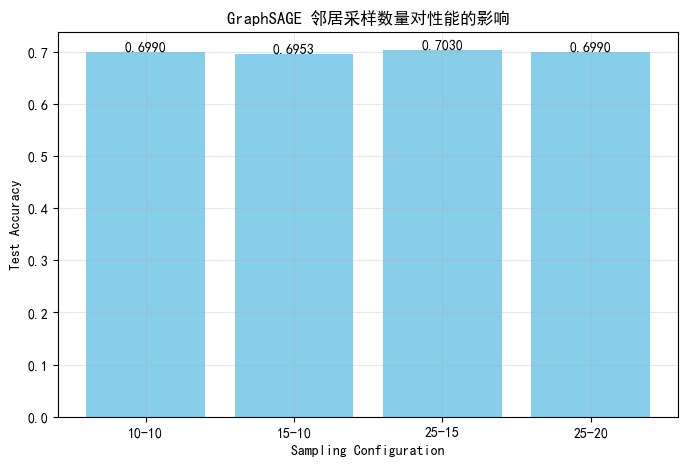

In [28]:
# ============================================================
# 消融实验：GraphSAGE 邻居采样数量影响
# ============================================================
print("\n" + "="*50)
print("消融实验：GraphSAGE 采样数量")
print("="*50)

sampling_configs = [
    ([10, 10], "10-10"),
    ([15, 10], "15-10"),
    ([25, 15], "25-15"),
    ([25, 20], "25-20")   # 当前默认
]

sampling_results = []
for neigh, label in sampling_configs:
    print(f"\n>>> 测试采样配置: {label}")
    # 重新构造 DataLoader
    train_loader_s = NeighborLoader(
        data,
        input_nodes=train_idx,
        num_neighbors=neigh,
        batch_size=1024,
        shuffle=True
    )
    valid_loader_s = NeighborLoader(
        data,
        input_nodes=valid_idx,
        num_neighbors=neigh,
        batch_size=1024,
        shuffle=False
    )
    test_loader_s = NeighborLoader(
        data,
        input_nodes=test_idx,
        num_neighbors=neigh,
        batch_size=1024,
        shuffle=False
    )
    
    model = GraphSAGE(data.x.size(1), 256, dataset.num_classes, dropout=0.3).to(device)
    # 使用 run_model 快速验证（增加到 100 个 epoch）
    _, val_acc, test_acc, _, _ = run_model(
        model=model,
        model_name=f"SAGE_{label}",
        train_loader=train_loader_s,
        valid_loader=valid_loader_s,
        test_loader=test_loader_s,
        epochs=100,          # 从 50 增加到 100
        lr=0.003,
        weight_decay=5e-4,
        dropout=0.3
    )
    sampling_results.append({"Config": label, "Val Acc": val_acc, "Test Acc": test_acc})

sampling_df = pd.DataFrame(sampling_results)
print("\n采样消融结果：")
print(sampling_df)

# 可视化
plt.figure(figsize=(8,5))
plt.bar(sampling_df["Config"], sampling_df["Test Acc"], color='skyblue')
plt.xlabel("Sampling Configuration")
plt.ylabel("Test Accuracy")
plt.title("GraphSAGE 邻居采样数量对性能的影响")
for i, row in sampling_df.iterrows():
    plt.text(i, row["Test Acc"]+0.002, f"{row['Test Acc']:.4f}", ha='center')
plt.grid(alpha=0.3)
plt.show()


消融实验：APPNP 不同 K 值对比

>>> 测试 APPNP K=1


c:\Users\26099\.conda\envs\deeplearning\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


★ Best model saved to ./saved_models\appnp_k=1_val0.6578_20260622_204638.pt
[APPNP_K=1] Epoch 001 | Loss 1.5894 | Val 0.6578 | Test 0.6534
★ Best model saved to ./saved_models\appnp_k=1_val0.6657_20260622_204644.pt
[APPNP_K=1] Epoch 002 | Loss 1.1745 | Val 0.6657 | Test 0.6526
★ Best model saved to ./saved_models\appnp_k=1_val0.6739_20260622_204650.pt
[APPNP_K=1] Epoch 003 | Loss 1.1272 | Val 0.6739 | Test 0.6702
★ Best model saved to ./saved_models\appnp_k=1_val0.6763_20260622_204656.pt
[APPNP_K=1] Epoch 004 | Loss 1.1017 | Val 0.6763 | Test 0.6690
★ Best model saved to ./saved_models\appnp_k=1_val0.6794_20260622_204702.pt
[APPNP_K=1] Epoch 005 | Loss 1.0848 | Val 0.6794 | Test 0.6755
[APPNP_K=1] Epoch 006 | Loss 1.0679 | Val 0.6768 | Test 0.6703
★ Best model saved to ./saved_models\appnp_k=1_val0.6800_20260622_204714.pt
[APPNP_K=1] Epoch 007 | Loss 1.0580 | Val 0.6800 | Test 0.6679
★ Best model saved to ./saved_models\appnp_k=1_val0.6813_20260622_204720.pt
[APPNP_K=1] Epoch 008 | Los

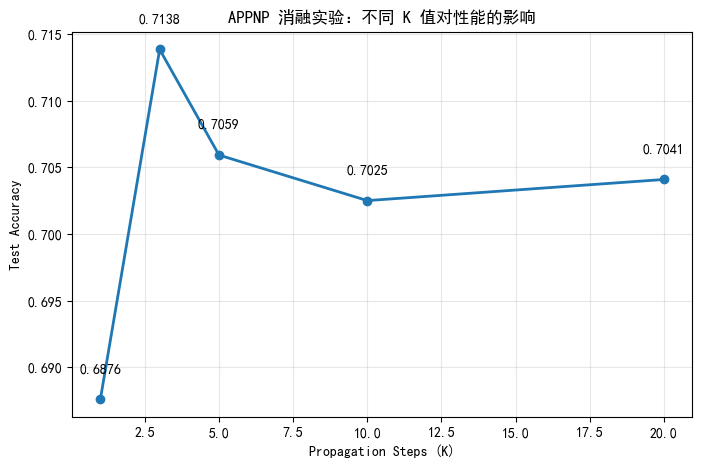

In [29]:
# ============================================================
# 消融实验：APPNP 传播步数 K 的影响
# ============================================================
print("\n" + "="*50)
print("消融实验：APPNP 不同 K 值对比")
print("="*50)

k_values = [1, 3, 5, 10, 20]
ablation_results = []

for k in k_values:
    print(f"\n>>> 测试 APPNP K={k}")
    
    # 手动构建带自定义 K 的模型
    class APPNPNetCustom(nn.Module):
        def __init__(self, in_channels, hidden_channels, out_channels, K, alpha=0.1, dropout=0.5):
            super().__init__()
            self.lin1 = nn.Linear(in_channels, hidden_channels)
            self.lin2 = nn.Linear(hidden_channels, out_channels)
            self.prop = APPNP(K=K, alpha=alpha)
            self.dropout = dropout

        def forward(self, x, edge_index):
            x = self.lin1(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = self.lin2(x)
            x = self.prop(x, edge_index)
            return x

    model = APPNPNetCustom(
        in_channels=data.x.size(1),
        hidden_channels=256,
        out_channels=dataset.num_classes,
        K=k
    )
    
    # 复用 run_model 函数（需要把 dropout 传进去，因为自定义模型也有 dropout）
    # 为简单起见，直接调用 run_model，但需要确保 run_model 能够设置 dropout
    # 由于 run_model 中用 hasattr(model, 'dropout')，可以正常工作
    best_model, best_val, best_test, loss_curve, val_curve = run_model(
        model=model,
        model_name=f"APPNP_K={k}",
        train_loader=train_loader,
        valid_loader=valid_loader,
        test_loader=test_loader,
        epochs=200,
        lr=0.003,
        weight_decay=5e-4,
        dropout=0.3
    )
    
    ablation_results.append({
        "K": k,
        "Best Val": best_val,
        "Best Test": best_test
    })

# 打印消融结果
ablation_df = pd.DataFrame(ablation_results)
print("\n消融实验结果：")
print(ablation_df)

# 绘制消融曲线
plt.figure(figsize=(8, 5))
plt.plot(ablation_df["K"], ablation_df["Best Test"], marker='o', linestyle='-', linewidth=2)
plt.xlabel("Propagation Steps (K)")
plt.ylabel("Test Accuracy")
plt.title("APPNP 消融实验：不同 K 值对性能的影响")
plt.grid(alpha=0.3)
for i, row in ablation_df.iterrows():
    plt.text(row["K"], row["Best Test"] + 0.002, f"{row['Best Test']:.4f}", ha='center')
plt.show()

In [30]:
results_df = pd.DataFrame({
    "Model": [r["Model"] for r in all_results],
    "Best Val": [r["Best Val"] for r in all_results],
    "Best Test": [r["Best Test"] for r in all_results]
})

results_df

,Model,Best Val,Best Test
0,MLP,0.578174,0.555213
1,GCN,0.716803,0.713351
2,SAGE,0.712675,0.707878
3,GAT,0.716400,0.709792
4,APPNP,0.715024,0.699792


In [31]:
results_df = results_df.sort_values(
    by="Best Test",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,Best Val,Best Test
0,GCN,0.716803,0.713351
1,GAT,0.716400,0.709792
2,SAGE,0.712675,0.707878
3,APPNP,0.715024,0.699792
4,MLP,0.578174,0.555213


In [32]:
results_df.to_csv(
    "node_classification_results.csv",
    index=False
)

print("实验结果已保存")

实验结果已保存


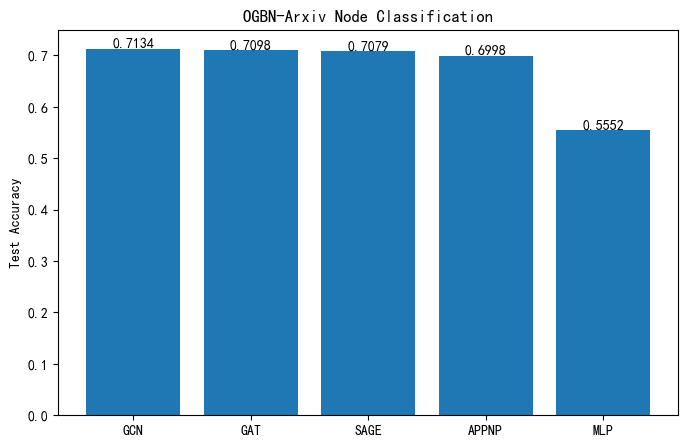

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Best Test"]
)

plt.ylabel("Test Accuracy")
plt.title("OGBN-Arxiv Node Classification")

for i, v in enumerate(results_df["Best Test"]):
    plt.text(
        i,
        v + 0.002,
        f"{v:.4f}",
        ha='center'
    )

plt.show()

In [34]:
# ============================================================
# 自动选择最佳模型并打印网络结构（用于报告）
# ============================================================

from torchinfo import summary
import torch

# 1. 从 results_df 中选出测试准确率最高的模型
best_model_name = results_df.iloc[0]["Model"]   # results_df 已按 Best Test 降序排列
print(f"最佳模型（按测试准确率）：{best_model_name}")

# 2. 构建该模型（使用与实验相同的参数）
if best_model_name == "GAT":
    hidden = 64
else:
    hidden = 256

model = build_model(
    model_name=best_model_name.lower(),
    in_channels=data.x.size(1),
    hidden_channels=hidden,
    out_channels=dataset.num_classes
)

# 为了摘要，将模型移至 CPU，避免 CUDA 内存和索引问题
model = model.to('cpu')

# 获取 CPU 上的原始数据（避免从 GPU 截取触发 device-side assert）
data_cpu = dataset[0]

# 3. 准备示例输入
sample_size = 100
sample_x = data_cpu.x[:sample_size]   # [100, 特征维度]

# 筛选两端节点都在前 sample_size 个节点中的边
mask = (data_cpu.edge_index[0] < sample_size) & (data_cpu.edge_index[1] < sample_size)
sample_edge = data_cpu.edge_index[:, mask]   # [2, 有效边数]

# 4. 使用 torchinfo 生成摘要（verbose=0 抑制打印，直接返回对象）
model_stats = summary(model, input_data=[sample_x, sample_edge], verbose=0)
model_summary_str = str(model_stats)   # 转为字符串

# 打印到控制台（方便查看）
print("\n" + "="*60)
print("模型结构摘要：")
print("="*60)
print(model_summary_str)

# 保存到文件
with open("best_model_summary.txt", "w", encoding='utf-8') as f:
    f.write(model_summary_str)
print("\n模型结构摘要已保存至 best_model_summary.txt")


最佳模型（按测试准确率）：GCN

模型结构摘要：
Layer (type:depth-idx)                   Output Shape              Param #
GCN                                      [100, 40]                 --
├─GCNConv: 1-1                           [100, 256]                256
│    └─Linear: 2-1                       [100, 256]                32,768
│    └─SumAggregation: 2-2               [100, 256]                --
├─GCNConv: 1-2                           [100, 40]                 40
│    └─Linear: 2-3                       [100, 40]                 10,240
│    └─SumAggregation: 2-4               [100, 40]                 --
Total params: 43,304
Trainable params: 43,304
Non-trainable params: 0
Total mult-adds (M): 4.30
Input size (MB): 86.70
Forward/backward pass size (MB): 0.24
Params size (MB): 0.17
Estimated Total Size (MB): 87.11

模型结构摘要已保存至 best_model_summary.txt


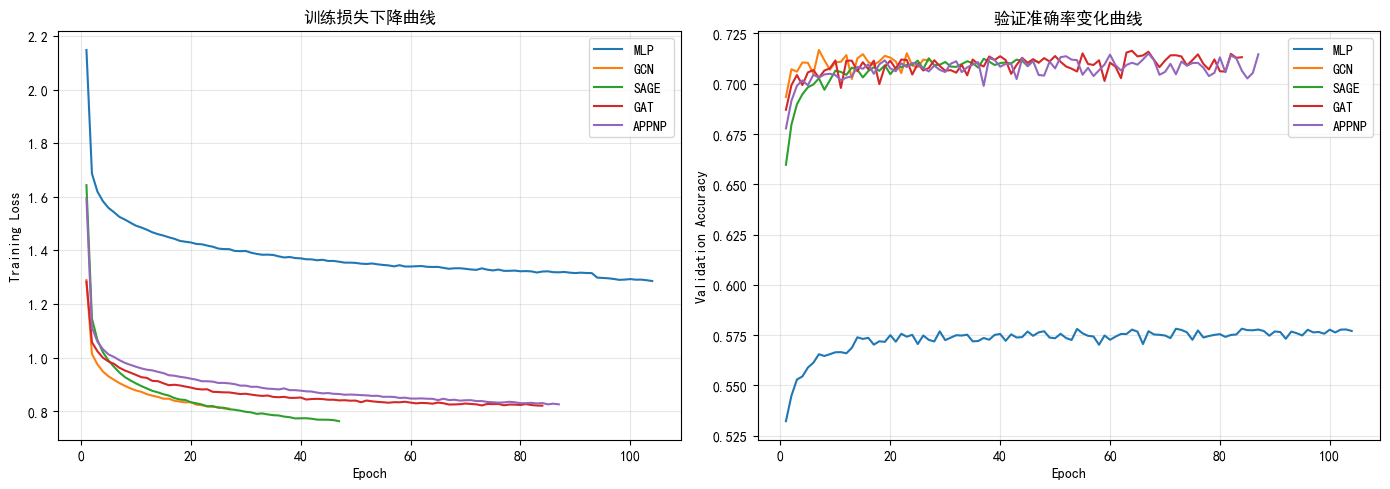


最佳模型（按测试准确率）：GCN

所有模型性能对比：
Model  Best Val  Best Test
  GCN  0.716803   0.713351
  GAT  0.716400   0.709792
 SAGE  0.712675   0.707878
APPNP  0.715024   0.699792
  MLP  0.578174   0.555213

正在从 ./saved_models 加载最佳模型...
找到最佳模型文件：gcn_val0.7168_20260622_193930.pt
加载成功！验证准确率：0.7168，测试准确率：0.7134
✅ 模型成功加载到 CPU，开始生成混淆矩阵和 t-SNE...



C:\Users\26099\AppData\Local\Temp\ipykernel_11188\2931254379.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_checkpoint_path, map_location=

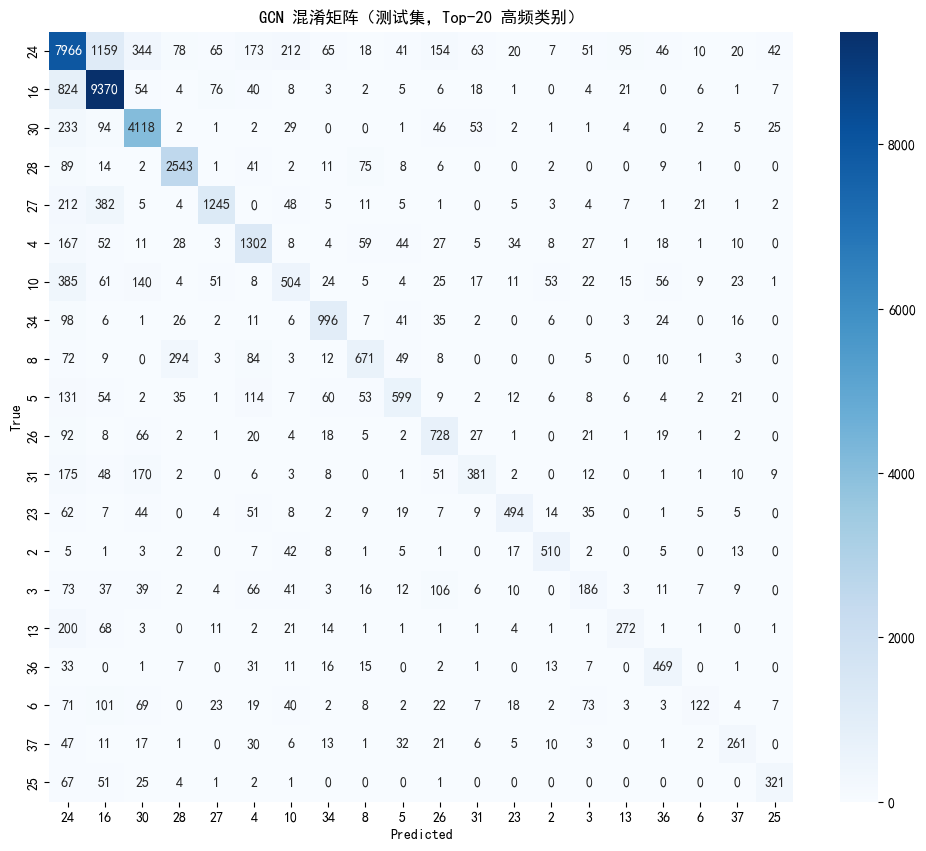

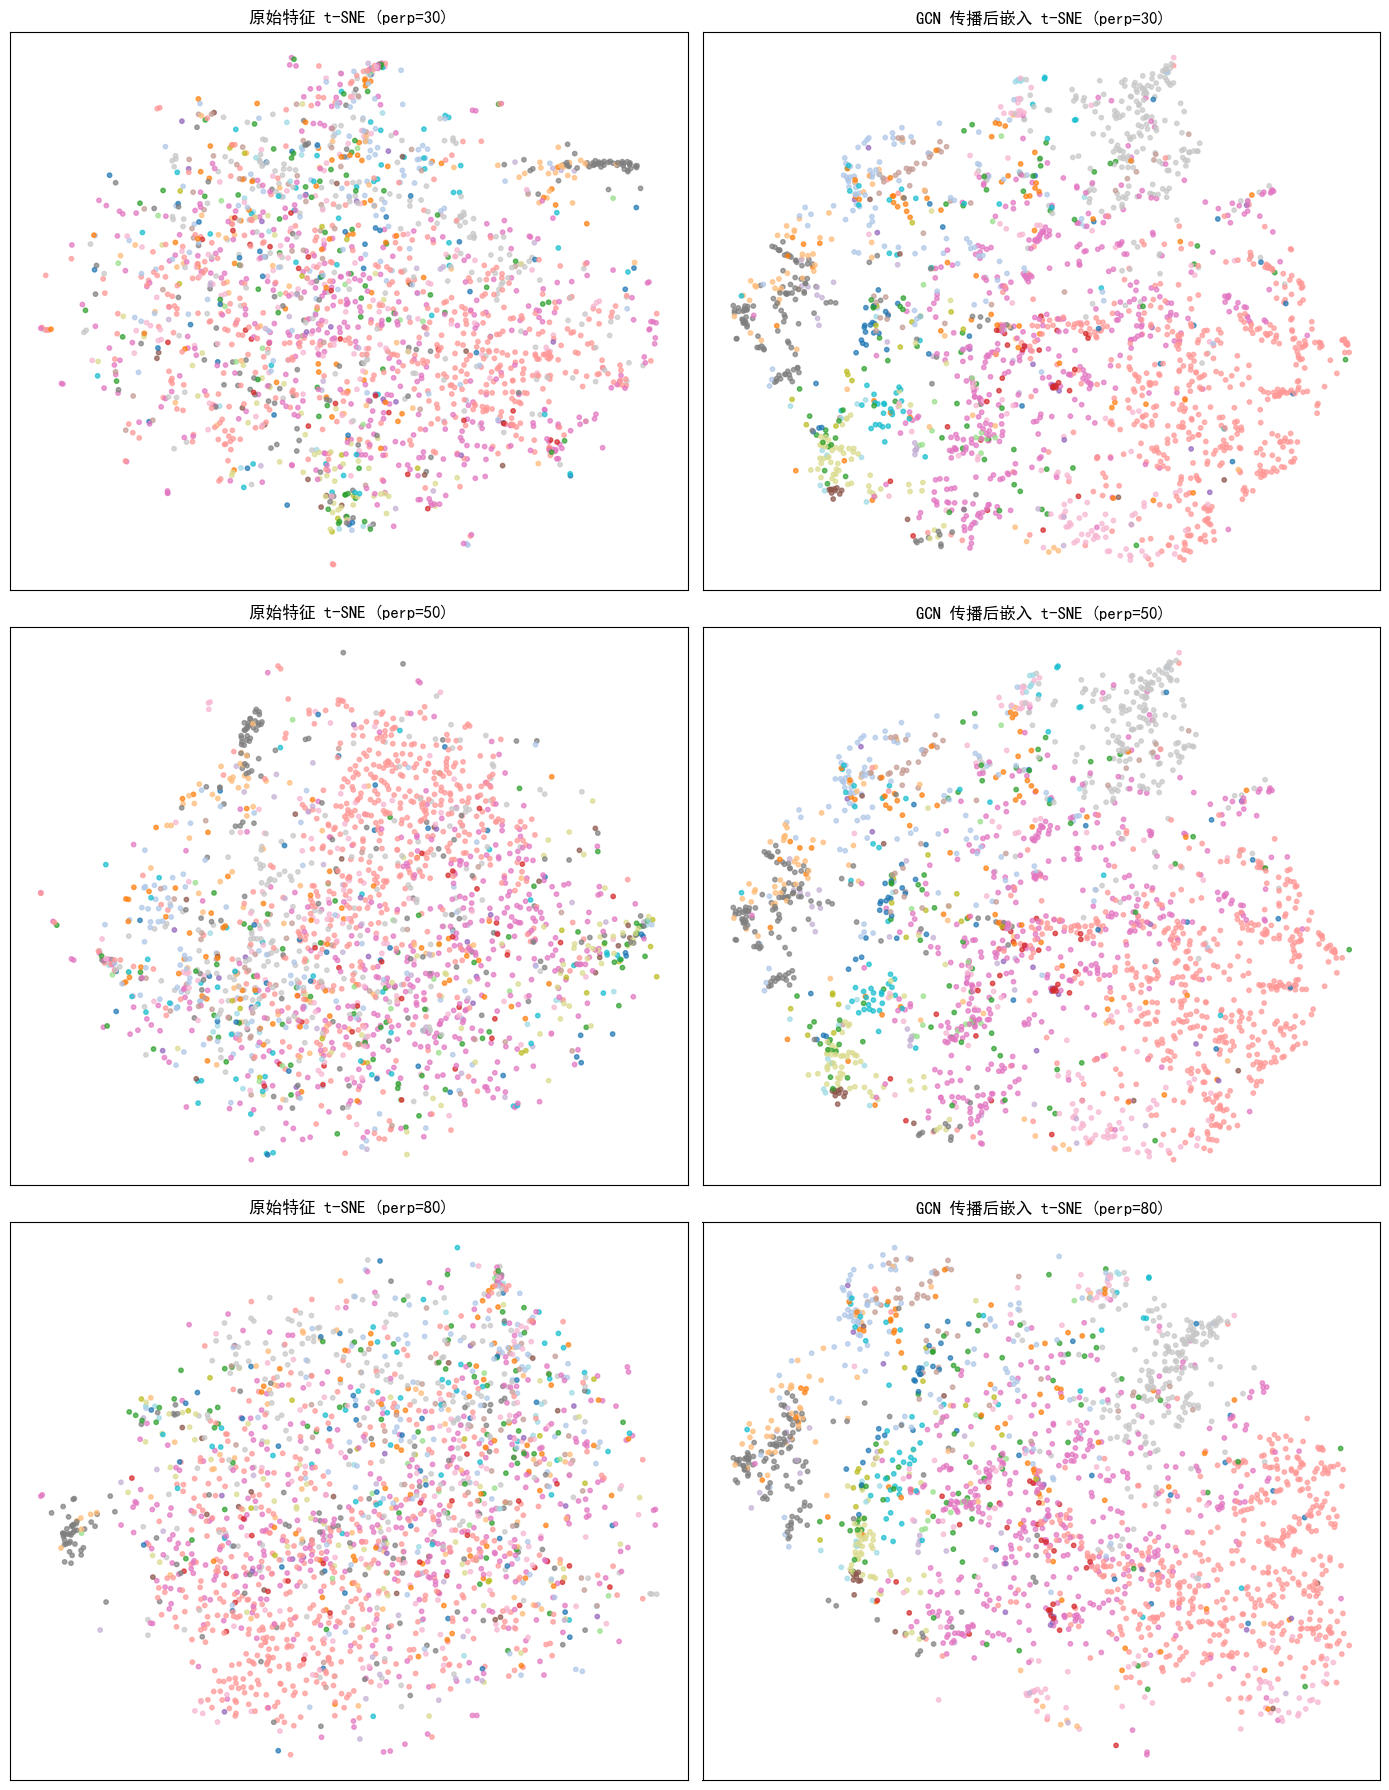

✅ 所有可视化已完成！


In [35]:
# ============================================================
# 增强可视化（从硬盘加载最佳模型，独立于内存变量）
# ============================================================

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import numpy as np
import os
import glob
import re
from torch_geometric.loader import NeighborLoader

# 设置 CPU 设备
cpu_device = torch.device('cpu')

# ----- 1. 绘制训练曲线（仍然使用 all_results 中的历史记录）-----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for res in all_results:
    model_name = res["Model"]
    loss_curve = res["Loss Curve"]
    val_curve = res["Val Curve"]
    epochs = range(1, len(loss_curve) + 1)
    
    axes[0].plot(epochs, loss_curve, label=model_name, linewidth=1.5)
    axes[1].plot(epochs, val_curve, label=model_name, linewidth=1.5)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("训练损失下降曲线")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("验证准确率变化曲线")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----- 2. 结果表格 -----
best_model_name = results_df.iloc[0]["Model"]
print(f"\n最佳模型（按测试准确率）：{best_model_name}")
print("\n所有模型性能对比：")
print(results_df.to_string(index=False))

# ----- 3. 从硬盘加载最佳模型（核心修改）-----
print(f"\n正在从 {SAVE_DIR} 加载最佳模型...")

# 确定隐藏层维度
if best_model_name == "GAT":
    hidden = 64
else:
    hidden = 256

# 查找该模型对应的所有保存文件
pattern = os.path.join(SAVE_DIR, f"{best_model_name.lower()}_val*.pt")
files = glob.glob(pattern)

if not files:
    raise FileNotFoundError(f"在 {SAVE_DIR} 中未找到 {best_model_name} 的保存文件！")

# 按验证准确率排序，选出最佳文件
def extract_val_from_filename(fname):
    match = re.search(r'_val([\d.]+)_', fname)
    return float(match.group(1)) if match else 0.0

best_checkpoint_path = max(files, key=extract_val_from_filename)
print(f"找到最佳模型文件：{os.path.basename(best_checkpoint_path)}")

# 加载检查点（强制映射到 CPU）
checkpoint = torch.load(best_checkpoint_path, map_location='cpu')
print(f"加载成功！验证准确率：{checkpoint['best_val']:.4f}，测试准确率：{checkpoint['best_test']:.4f}")

# 重建模型并加载权重
model = build_model(
    model_name=best_model_name.lower(),
    in_channels=data.x.size(1),
    hidden_channels=hidden,
    out_channels=dataset.num_classes
).to(cpu_device)

model.load_state_dict(checkpoint["state_dict"])
model.eval()
print("✅ 模型成功加载到 CPU，开始生成混淆矩阵和 t-SNE...\n")

# 将数据移至 CPU
data_cpu = data.to(cpu_device)
test_loader_cpu = NeighborLoader(
    data_cpu,
    input_nodes=test_idx.cpu(),
    num_neighbors=[25, 20],
    batch_size=1024,
    shuffle=False
)

# ----- 混淆矩阵 -----
@torch.no_grad()
def get_node_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        out = model(batch.x, batch.edge_index)
        out = out[:batch.batch_size]
        pred = out.argmax(dim=-1)
        all_preds.append(pred.cpu())
        all_labels.append(batch.y[:batch.batch_size].view(-1).cpu())
    return torch.cat(all_preds), torch.cat(all_labels)

y_pred_node, y_true_node = get_node_predictions(model, test_loader_cpu)

unique_labels, counts = torch.unique(y_true_node, return_counts=True)
top20_idx = torch.argsort(counts, descending=True)[:20]
mask = torch.isin(y_true_node, top20_idx) & torch.isin(y_pred_node, top20_idx)
y_true_filtered = y_true_node[mask]
y_pred_filtered = y_pred_node[mask]

if len(y_true_filtered) > 0:
    remap = {int(v): i for i, v in enumerate(top20_idx.tolist())}
    y_true_remap = torch.tensor([remap[int(x)] for x in y_true_filtered])
    y_pred_remap = torch.tensor([remap[int(x)] for x in y_pred_filtered])
    cm = confusion_matrix(y_true_remap, y_pred_remap)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=top20_idx.tolist(),
                yticklabels=top20_idx.tolist())
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{best_model_name} 混淆矩阵（测试集，Top-20 高频类别）")
    plt.show()
else:
    print("警告：过滤后无样本，跳过混淆矩阵。")

# ----- t-SNE 可视化 -----
sample_size = min(2000, len(test_idx))
sample_indices = test_idx[:sample_size].cpu()

x_original = data_cpu.x[sample_indices].numpy()
y_sample = data_cpu.y[sample_indices].view(-1).numpy()

with torch.no_grad():
    out_logits = model(data_cpu.x, data_cpu.edge_index)
    out_logits = out_logits[sample_indices].numpy()

perplexities = [30, 50, 80]
fig, axes = plt.subplots(len(perplexities), 2, figsize=(14, 6*len(perplexities)))
for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp, max_iter=300)
    x_tsne = tsne.fit_transform(x_original)
    logits_tsne = tsne.fit_transform(out_logits)
    axes[i, 0].scatter(x_tsne[:, 0], x_tsne[:, 1], c=y_sample, cmap='tab20', s=10, alpha=0.7)
    axes[i, 0].set_title(f"原始特征 t-SNE (perp={perp})")
    axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
    axes[i, 1].scatter(logits_tsne[:, 0], logits_tsne[:, 1], c=y_sample, cmap='tab20', s=10, alpha=0.7)
    axes[i, 1].set_title(f"{best_model_name} 传播后嵌入 t-SNE (perp={perp})")
    axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])
plt.tight_layout()
plt.show()

print("✅ 所有可视化已完成！")


===== BEST MODEL =====
GCN

===== BEST PARAMS =====
{'lr': 0.0040813523255633566, 'dropout': 0.24729048291333103, 'weight_decay': 4.6386785523037966e-05}

===== DropEdge Ablation =====

Baseline
Epoch 000 | loss 3.8688 | val 0.2266
Epoch 001 | loss 3.4272 | val 0.2826
Epoch 002 | loss 3.2018 | val 0.1646
Epoch 003 | loss 3.1042 | val 0.3088
Epoch 004 | loss 3.0439 | val 0.3432
Epoch 005 | loss 2.9917 | val 0.3706
Epoch 006 | loss 2.9421 | val 0.3650
Epoch 007 | loss 2.8808 | val 0.3662
Epoch 008 | loss 2.8174 | val 0.3816
Epoch 009 | loss 2.7593 | val 0.4002
Epoch 010 | loss 2.7115 | val 0.4190
Epoch 011 | loss 2.6601 | val 0.4327
Epoch 012 | loss 2.6127 | val 0.4425
Epoch 013 | loss 2.5679 | val 0.4523
Epoch 014 | loss 2.5211 | val 0.4565
Epoch 015 | loss 2.4792 | val 0.4581
Epoch 016 | loss 2.4419 | val 0.4612
Epoch 017 | loss 2.4004 | val 0.4657
Epoch 018 | loss 2.3616 | val 0.4746
Epoch 019 | loss 2.3263 | val 0.4845
Epoch 020 | loss 2.2901 | val 0.4917
Epoch 021 | loss 2.2545 | v

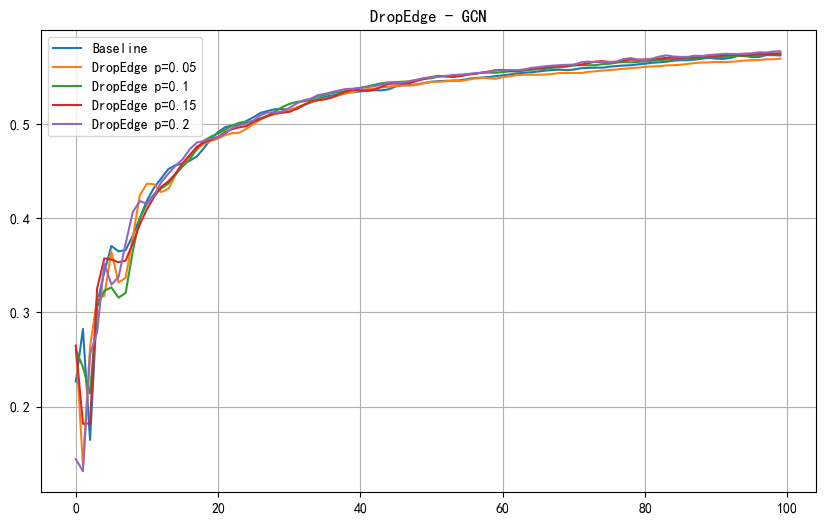

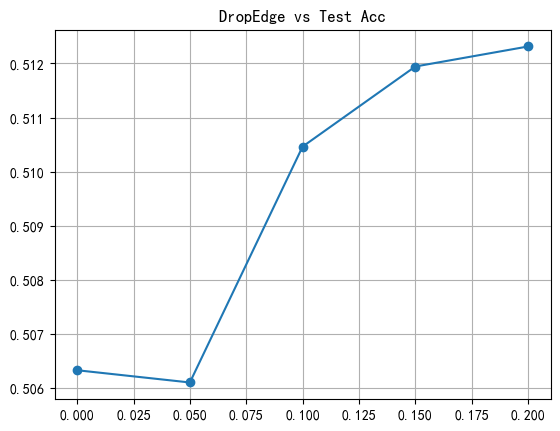

In [36]:
# ============================================================
# DropEdge 消融实验（最终稳定版 + Optuna best params）
# ============================================================

import torch
import copy
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.utils import dropout_edge

# ============================================================
# 1. 获取最佳模型 + 最优参数（修复大小写问题）
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_model_key = best_model_name.lower()

print("\n===== BEST MODEL =====")
print(best_model_name)

# ✔ 防炸：统一 key
if best_model_key not in best_params_dict:
    raise KeyError(f"{best_model_key} not in best_params_dict")

best_params = best_params_dict[best_model_key]

lr = best_params.get("lr", 0.003)
weight_decay = best_params.get("weight_decay", 5e-4)
dropout = best_params.get("dropout", 0.3)

print("\n===== BEST PARAMS =====")
print(best_params)

# ============================================================
# 2. loss（必须一致）
# ============================================================

import torch.nn as nn
criterion = nn.CrossEntropyLoss()

# ============================================================
# 3. data（OGBN标准）
# ============================================================

data = dataset[0]
data.y = data.y.squeeze().long()

split_idx = dataset.get_idx_split()
n = data.num_nodes

data.train_mask = torch.zeros(n, dtype=torch.bool)
data.val_mask = torch.zeros(n, dtype=torch.bool)
data.test_mask = torch.zeros(n, dtype=torch.bool)

data.train_mask[split_idx["train"]] = True
data.val_mask[split_idx["valid"]] = True
data.test_mask[split_idx["test"]] = True

data = data.to(device)
data.train_mask = data.train_mask.to(device)
data.val_mask = data.val_mask.to(device)
data.test_mask = data.test_mask.to(device)

# ============================================================
# 4. train / dropedge train
# ============================================================

def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()
    return loss.item()


def train_with_dropedge(model, data, optimizer, drop_p):
    model.train()
    optimizer.zero_grad()

    edge_index, _ = dropout_edge(data.edge_index, p=drop_p, training=True)

    out = model(data.x, edge_index)

    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()
    return loss.item()

# ============================================================
# 5. eval
# ============================================================

@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    return (pred[mask] == data.y[mask]).float().mean().item()

# ============================================================
# 6. run experiment（核心修复）
# ============================================================

def run_experiment(model, drop_p=0.0, epochs=100):

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val = 0
    best_test = 0

    val_curve = []
    loss_curve = []

    best_state = None

    for epoch in range(epochs):

        if drop_p > 0:
            loss = train_with_dropedge(model, data, optimizer, drop_p)
        else:
            loss = train(model, data, optimizer)

        val_acc = evaluate(model, data, data.val_mask)
        test_acc = evaluate(model, data, data.test_mask)

        val_curve.append(val_acc)
        loss_curve.append(loss)

        if val_acc > best_val:
            best_val = val_acc
            best_test = test_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch:03d} | loss {loss:.4f} | val {val_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val, best_test, loss_curve, val_curve

# ============================================================
# 7. 开始 DropEdge 消融
# ============================================================

drop_p_values = [0.0, 0.05, 0.1, 0.15, 0.2]

results = []

print("\n===== DropEdge Ablation =====")

for drop_p in drop_p_values:

    label = f"DropEdge p={drop_p}" if drop_p > 0 else "Baseline"

    print("\n", "=" * 40)
    print(label)

    # ✔ 必须用 BEST MODEL（关键）
    model = build_model(
        model_name=best_model_key,
        in_channels=data.x.size(1),
        hidden_channels=256,
        out_channels=dataset.num_classes
    )

    val_acc, test_acc, loss_curve, val_curve = run_experiment(
        model,
        drop_p=drop_p,
        epochs=100
    )

    results.append({
        "drop_p": drop_p,
        "label": label,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_curve": val_curve
    })

# ============================================================
# 8. 结果
# ============================================================

df = pd.DataFrame(results)
print(df[["drop_p", "test_acc"]])

plt.figure(figsize=(10,6))
for r in results:
    plt.plot(r["val_curve"], label=r["label"])
plt.legend()
plt.title(f"DropEdge - {best_model_name}")
plt.grid()
plt.show()

plt.figure()
plt.plot(df["drop_p"], df["test_acc"], marker="o")
plt.title("DropEdge vs Test Acc")
plt.grid()
plt.show()

In [37]:
# ============================================================
# 链接预测实验
# ============================================================

import os
import copy
import time
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, f1_score
)
from scipy.stats import pearsonr
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import remove_self_loops, negative_sampling, degree
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.nn import SAGEConv
from ogb.nodeproppred import PygNodePropPredDataset

# 在 import 之后加入这行，减少显存碎片
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# -------------------- 设备设置 --------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -------------------- 加载 OGBN-Arxiv 数据 --------------------
dataset = PygNodePropPredDataset(name='ogbn-arxiv')
data = dataset[0]  # 包含 x, edge_index, y 等
data.edge_index, _ = remove_self_loops(data.edge_index)  # 移除自环
print(f"Dataset: {data}")
print(f"Nodes: {data.num_nodes}, Edges: {data.edge_index.shape[1]}")

Using device: cuda
Dataset: Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
Nodes: 169343, Edges: 1166243


c:\Users\26099\.conda\envs\deeplearning\lib\site-packages\ogb\nodeproppred\dataset_pyg.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices = torch.lo

In [74]:
# ============================================================
# 严格划分正边 (OGB 官方时间分割：按论文发表年份)
# 并生成对应的负样本（排除所有真实边）
# ============================================================

# 1. 获取年份信息
year = data.node_year.view(-1)  # shape: [num_nodes]
src_year = year[data.edge_index[0]]  # 每条边源节点的年份

# 2. 按年份划分正边（OGB官方标准）
train_mask = src_year <= 2017
val_mask   = src_year == 2018
test_mask  = src_year >= 2019

train_pos = data.edge_index[:, train_mask]
val_pos   = data.edge_index[:, val_mask]
test_pos  = data.edge_index[:, test_mask]

print(f"时间分割结果 -> Train正边: {train_pos.shape}, Val正边: {val_pos.shape}, Test正边: {test_pos.shape}")

时间分割结果 -> Train正边: torch.Size([2, 378578]), Val正边: torch.Size([2, 247936]), Test正边: torch.Size([2, 539729])


In [75]:
# 3. 合并所有真实边（用于负采样排除）
all_pos_edges = torch.cat([train_pos, val_pos, test_pos], dim=1)
num_nodes = data.num_nodes

# 4. 定义负采样函数
def safe_negative_sampling(pos_edges, num_samples):
    """生成负样本，确保不与任何真实边重叠"""
    return negative_sampling(
        edge_index=all_pos_edges,
        num_nodes=num_nodes,
        num_neg_samples=num_samples
    )

# 5. 生成负样本
train_neg = safe_negative_sampling(train_pos, train_pos.size(1))
val_neg   = safe_negative_sampling(val_pos, val_pos.size(1))
test_neg  = safe_negative_sampling(test_pos, test_pos.size(1))

# 6. 打印结果
print(f"Train负边: {train_neg.shape}, Val负边: {val_neg.shape}, Test负边: {test_neg.shape}")

Train负边: torch.Size([2, 378578]), Val负边: torch.Size([2, 247936]), Test负边: torch.Size([2, 539729])


In [39]:
# ============================================================
# 构建训练图（仅包含训练正边，避免信息泄漏）
# ============================================================

train_graph = copy.deepcopy(data)
train_graph.edge_index = train_pos

# 合并评估边和标签
val_edges = torch.cat([val_pos, val_neg], dim=1)
val_labels = torch.cat([torch.ones(val_pos.size(1)), torch.zeros(val_neg.size(1))])

test_edges = torch.cat([test_pos, test_neg], dim=1)
test_labels = torch.cat([torch.ones(test_pos.size(1)), torch.zeros(test_neg.size(1))])

print(f"Val edges: {val_edges.shape}, Val labels: {val_labels.shape}")
print(f"Test edges: {test_edges.shape}, Test labels: {test_labels.shape}")

Val edges: torch.Size([2, 495872]), Val labels: torch.Size([495872])
Test edges: torch.Size([2, 1079458]), Test labels: torch.Size([1079458])


In [40]:
# ============================================================
# 训练 Loader（优化显存版）
# ============================================================

# 构造训练边（正 + 负）
train_edge_index = torch.cat([train_pos, train_neg], dim=1)
train_edge_label = torch.cat([
    torch.ones(train_pos.size(1)),
    torch.zeros(train_neg.size(1))
])

# 打乱训练边
perm_train = torch.randperm(train_edge_index.size(1))
train_edge_index = train_edge_index[:, perm_train]
train_edge_label = train_edge_label[perm_train]

# ✅ 关键修改：降低邻居采样数 [5,5]，batch_size 降至 256（4G 显存够用）
train_loader = LinkNeighborLoader(
    train_graph,
    num_neighbors=[5, 5],          # 从 [15,10] 降低
    edge_label_index=train_edge_index,
    edge_label=train_edge_label,
    batch_size=256,                # 从 1024 降低
    shuffle=True,
    num_workers=0,
)

print(f"Train edge index: {train_edge_index.shape}")
print(f"Train edge label: {train_edge_label.shape}")
print("DataLoader ready.")

Train edge index: torch.Size([2, 757156])
Train edge label: torch.Size([757156])
DataLoader ready.


In [41]:
# ============================================================
# 定义 GraphSAGE Encoder（增强版：+ LayerNorm）
# ============================================================

class GraphSAGEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=128, out_channels=64, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.norm = torch.nn.LayerNorm(out_channels)   # 新增：稳定训练
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.norm(x)   # 新增：LayerNorm
        return x

In [42]:
# ============================================================
# 定义 GAT 编码器
# ============================================================

from torch_geometric.nn import GATConv

class GATEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=128, out_channels=64, heads=2, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        # 注意：第二层 concat=False，将多头输出合并为 out_channels
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)
        self.norm = torch.nn.LayerNorm(out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.norm(x)
        return x

In [43]:
# ============================================================
# 定义多种 Decoder（MLP、内积、余弦）
# ============================================================

class MLPDecoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=128):
        super().__init__()
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(in_channels * 2, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, 1)
        )

    def forward(self, z, edge_index):
        src, dst = edge_index
        h = torch.cat([z[src], z[dst]], dim=1)
        return self.mlp(h).squeeze()

class InnerProductDecoder(torch.nn.Module):
    def forward(self, z, edge_index):
        src, dst = edge_index
        return (z[src] * z[dst]).sum(dim=1)

class CosineDecoder(torch.nn.Module):
    def __init__(self, scale=1.0):
        super().__init__()
        self.scale = torch.nn.Parameter(torch.tensor(scale))

    def forward(self, z, edge_index):
        src, dst = edge_index
        z_src = F.normalize(z[src], p=2, dim=1)
        z_dst = F.normalize(z[dst], p=2, dim=1)
        return (z_src * z_dst).sum(dim=1) * self.scale


In [44]:
# ============================================================
# 最终修复版：Link Prediction 训练器
# 修复硬负采样 topk 边界问题
# ============================================================

import time
import copy
import torch
import torch.nn.functional as F
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.utils import negative_sampling

def train_link_model(encoder, decoder, train_loader, val_edges, val_labels,
                     data, all_pos_edges, train_pos, num_nodes,
                     epochs=100, lr=0.001, weight_decay=5e-4,
                     patience=20, eval_interval=5,
                     batch_size=128, accumulation_steps=4,
                     use_hard_negative=True,
                     hard_ratio=2,
                     max_candidates=30000,
                     chunk_size=10000,
                     num_neighbors=[10, 10]):

    device = next(encoder.parameters()).device
    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    criterion = torch.nn.BCEWithLogitsLoss()

    best_val_ap = -1
    best_state = None
    wait = 0
    history = {'loss': [], 'val_auc': [], 'val_ap': []}

    # ========== 1. 初始化 train_loader（保证有负样本） ==========
    if use_hard_negative:
        init_neg = negative_sampling(
            edge_index=all_pos_edges,
            num_nodes=num_nodes,
            num_neg_samples=train_pos.size(1),
            method='sparse'
        )
        train_edge_index = torch.cat([train_pos, init_neg], dim=1)
        train_edge_label = torch.cat([
            torch.ones(train_pos.size(1)),
            torch.zeros(init_neg.size(1))
        ])
        perm = torch.randperm(train_edge_index.size(1))
        train_loader = LinkNeighborLoader(
            data,
            num_neighbors=num_neighbors,
            edge_label_index=train_edge_index[:, perm],
            edge_label=train_edge_label[perm],
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,
        )
        print(f"✅ 初始训练集：正边 {train_pos.size(1)}，负边 {init_neg.size(1)}")

    # ========== 2. 硬负采样（显存安全 + 边界保护） ==========
    def hard_negative_sampling(pos_edges, num_neg_samples):
        encoder.eval()
        decoder.eval()
        with torch.no_grad():
            # 候选数 = num_neg_samples * hard_ratio，但不超过 max_candidates
            n_candidates = min(num_neg_samples * hard_ratio, max_candidates)
            n_candidates = max(n_candidates, 1000)  # 至少 1000 条

            candidate_neg = negative_sampling(
                edge_index=all_pos_edges,
                num_nodes=num_nodes,
                num_neg_samples=n_candidates,
                method='sparse'
            )

            if candidate_neg.size(1) == 0:
                print("⚠️ 硬负采样：未得到候选负边")
                return torch.empty(2, 0, dtype=torch.long, device='cpu')

            z = encoder(data.x.to(device), data.edge_index.to(device))

            scores_list = []
            for i in range(0, candidate_neg.size(1), chunk_size):
                batch_edges = candidate_neg[:, i:i+chunk_size].to(device)
                s = decoder(z, batch_edges).squeeze()
                scores_list.append(s.cpu())
            scores = torch.cat(scores_list, dim=0)

            k = min(num_neg_samples, scores.numel())
            if k <= 0:
                print("⚠️ 硬负采样：scores 为空")
                return torch.empty(2, 0, dtype=torch.long, device='cpu')

            top_scores, top_indices = torch.topk(scores, k)
            hard_neg = candidate_neg[:, top_indices.cpu()]
            return hard_neg

    # ========== 3. 训练循环 ==========
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        print(f"Epoch {epoch:03d} started at {time.strftime('%H:%M:%S')}")

        if use_hard_negative and epoch % 10 == 0 and epoch > 1:
            print("  🔄 更新硬负样本...")
            hard_neg = hard_negative_sampling(train_pos, train_pos.size(1))
            # 若硬负样本为空，则跳过本次更新
            if hard_neg.size(1) == 0:
                print("  ⚠️ 本次未生成硬负样本，跳过更新")
            else:
                train_edge_index = torch.cat([train_pos, hard_neg], dim=1)
                train_edge_label = torch.cat([
                    torch.ones(train_pos.size(1)),
                    torch.zeros(hard_neg.size(1))
                ])
                perm = torch.randperm(train_edge_index.size(1))
                train_loader = LinkNeighborLoader(
                    data,
                    num_neighbors=num_neighbors,
                    edge_label_index=train_edge_index[:, perm],
                    edge_label=train_edge_label[perm],
                    batch_size=batch_size,
                    shuffle=True,
                    num_workers=0,
                )

        encoder.train()
        decoder.train()
        total_loss = 0
        num_batches = 0
        optimizer.zero_grad()

        for i, batch in enumerate(train_loader):
            batch = batch.to(device)
            z = encoder(batch.x, batch.edge_index)
            scores = decoder(z, batch.edge_label_index)
            loss = criterion(scores, batch.edge_label.float())
            loss = loss / accumulation_steps
            loss.backward()

            if (i + 1) % accumulation_steps == 0:
                optimizer.step()
                optimizer.zero_grad()

            total_loss += loss.item() * accumulation_steps
            num_batches += 1

        if (i + 1) % accumulation_steps != 0:
            optimizer.step()
            optimizer.zero_grad()

        avg_loss = total_loss / num_batches
        history['loss'].append(avg_loss)
        print(f"Epoch {epoch:03d} finished in {time.time()-start_time:.2f}s, Loss: {avg_loss:.4f}")

        if epoch % eval_interval == 0:
            val_auc, val_ap, _, _ = evaluate(encoder, decoder, val_edges, val_labels)
            history['val_auc'].append(val_auc)
            history['val_ap'].append(val_ap)
            print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f} | Val AUC: {val_auc:.4f} AP: {val_ap:.4f}")

            if val_ap > best_val_ap:
                best_val_ap = val_ap
                best_state = {
                    'encoder': copy.deepcopy(encoder.state_dict()),
                    'decoder': copy.deepcopy(decoder.state_dict())
                }
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

        torch.cuda.empty_cache()

    if best_state is not None:
        encoder.load_state_dict(best_state['encoder'])
        decoder.load_state_dict(best_state['decoder'])

    return encoder, decoder, best_val_ap, history, best_state

In [45]:
# ============================================================
# 评估函数（严格使用训练图结构）
# ============================================================

@torch.no_grad()
def evaluate(encoder, decoder, eval_edges, eval_labels):
    encoder.eval()
    decoder.eval()

    # 🚨 关键修复：只用训练图进行消息传递，杜绝结构泄漏
    z = encoder(
        data.x.to(device),
        train_graph.edge_index.to(device)   # 这里必须是 train_graph！
    )

    # 批量推理（避免显存爆炸）
    batch_size = 4096
    all_preds = []
    num_edges = eval_edges.size(1)

    for start in range(0, num_edges, batch_size):
        end = min(start + batch_size, num_edges)
        edge_batch = eval_edges[:, start:end].to(device)
        pred_batch = torch.sigmoid(decoder(z, edge_batch))
        all_preds.append(pred_batch.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = eval_labels.numpy()

    auc = roc_auc_score(y_true, y_pred)
    ap = average_precision_score(y_true, y_pred)

    return auc, ap, y_pred, y_true

In [46]:
# ============================================================
# 消融实验（GraphSAGE）
# Random Negative vs Hard Negative
# 与主实验保持完全一致
# ============================================================

print("\n" + "=" * 60)
print("开始消融实验：Random Negative vs Hard Negative")
print("=" * 60)

ablation_configs = [
    {
        'name': 'Random Negative',
        'train_kwargs': {
            'batch_size': 128,
            'accumulation_steps': 4,
            'num_neighbors': [10, 10],
            'use_hard_negative': False,
            'hard_ratio': 2,
            'max_candidates': 30000,
            'chunk_size': 10000
        }
    },

    {
        'name': 'Hard Negative',
        'train_kwargs': {
            'batch_size': 128,
            'accumulation_steps': 4,
            'num_neighbors': [10, 10],
            'use_hard_negative': True,
            'hard_ratio': 2,
            'max_candidates': 30000,
            'chunk_size': 10000
        }
    }
]

ablation_results = {}

for config in ablation_configs:

    print("\n" + "=" * 50)
    print(f"正在训练：{config['name']}")
    print("=" * 50)

    # ==============================
    # GraphSAGE Encoder
    # ==============================
    encoder = GraphSAGEEncoder(
        in_channels=data.x.size(1),
        hidden_channels=128,
        out_channels=64,
        dropout=0.5
    ).to(device)

    # ==============================
    # 与主实验保持一致：MLPDecoder
    # ==============================
    decoder = MLPDecoder(
        in_channels=64,
        hidden_channels=128
    ).to(device)

    # ==============================
    # 训练
    # ==============================
    encoder, decoder, best_val_ap, history, best_state = train_link_model(
        encoder=encoder,
        decoder=decoder,
        train_loader=train_loader,

        val_edges=val_edges,
        val_labels=val_labels,

        data=data,
        all_pos_edges=all_pos_edges,
        train_pos=train_pos,
        num_nodes=data.num_nodes,

        epochs=100,
        lr=0.001,
        weight_decay=5e-4,

        patience=20,
        eval_interval=5,

        **config['train_kwargs']
    )

    # ==============================
    # 测试集评估
    # ==============================
    test_auc, test_ap, _, _ = evaluate(
        encoder,
        decoder,
        test_edges,
        test_labels
    )

    # ==============================
    # 保存结果
    # ==============================
    ablation_results[config['name']] = {
        'AUC': test_auc,
        'AP': test_ap,
        'encoder': encoder,
        'decoder': decoder,
        'history': history,
        'best_val_ap': best_val_ap
    }

    print(
        f"\n✅ {config['name']} "
        f"| Test AUC = {test_auc:.4f} "
        f"| Test AP = {test_ap:.4f}"
    )

print("\n" + "=" * 60)
print("Cell23 运行完成")
print("=" * 60)


开始消融实验：Random Negative vs Hard Negative

正在训练：Random Negative
Epoch 001 started at 21:36:40
Epoch 001 finished in 28.79s, Loss: 0.2250
Epoch 002 started at 21:37:09
Epoch 002 finished in 26.22s, Loss: 0.1430
Epoch 003 started at 21:37:35
Epoch 003 finished in 26.55s, Loss: 0.1334
Epoch 004 started at 21:38:02
Epoch 004 finished in 26.61s, Loss: 0.1281
Epoch 005 started at 21:38:28
Epoch 005 finished in 26.31s, Loss: 0.1240
Epoch 005 | Loss: 0.1240 | Val AUC: 0.8883 AP: 0.9036
Epoch 006 started at 21:38:55
Epoch 006 finished in 25.05s, Loss: 0.1217
Epoch 007 started at 21:39:20
Epoch 007 finished in 25.83s, Loss: 0.1201
Epoch 008 started at 21:39:46
Epoch 008 finished in 25.55s, Loss: 0.1183
Epoch 009 started at 21:40:11
Epoch 009 finished in 26.15s, Loss: 0.1175
Epoch 010 started at 21:40:38
Epoch 010 finished in 25.97s, Loss: 0.1181
Epoch 010 | Loss: 0.1181 | Val AUC: 0.8946 AP: 0.9113
Epoch 011 started at 21:41:04
Epoch 011 finished in 24.76s, Loss: 0.1172
Epoch 012 started at 21:41

In [47]:
# ============================================================
# 结果汇总 + 自动选择最佳模型（改进版）
# ============================================================

print("\n" + "=" * 60)
print("消融实验结果汇总")
print("=" * 60)

random_auc = ablation_results['Random Negative']['AUC']
random_ap  = ablation_results['Random Negative']['AP']
hard_auc = ablation_results['Hard Negative']['AUC']
hard_ap  = ablation_results['Hard Negative']['AP']

# 打印结果表格
print(f"{'Method':20s} {'AUC':>10s} {'AP':>10s}")
print("-" * 45)
print(f"{'Random Negative':20s} {random_auc:10.4f} {random_ap:10.4f}")
print(f"{'Hard Negative':20s} {hard_auc:10.4f} {hard_ap:10.4f}")
print("-" * 45)

auc_imp = (hard_auc - random_auc) * 100
ap_imp = (hard_ap - random_ap) * 100
print(f"AUC Improvement: {auc_imp:.2f}%")
print(f"AP  Improvement: {ap_imp:.2f}%")

# ============================================================
# 自动选择最佳模型（改进版）
# ============================================================

# 策略：AUC 提升超过 0.5% 则优先选择硬负采样
if auc_imp > 0.5:
    best_name = "Hard Negative"
    best_auc, best_ap = hard_auc, hard_ap
    best_encoder = ablation_results['Hard Negative']['encoder']
    best_decoder = ablation_results['Hard Negative']['decoder']
    best_history = ablation_results['Hard Negative']['history']
    print("\n🔹 选择依据：AUC 提升 {:.2f}%，整体排序能力更强。".format(auc_imp))
elif ap_imp > 0.5:
    best_name = "Hard Negative" if hard_ap > random_ap else "Random Negative"
    best_auc = hard_auc if best_name == "Hard Negative" else random_auc
    best_ap = hard_ap if best_name == "Hard Negative" else random_ap
    best_encoder = ablation_results[best_name]['encoder']
    best_decoder = ablation_results[best_name]['decoder']
    best_history = ablation_results[best_name]['history']
    print("\n🔹 选择依据：AP 提升 {:.2f}%，精确-召回平衡更优。".format(abs(ap_imp)))
else:
    best_name = "Hard Negative" if hard_auc > random_auc else "Random Negative"
    best_auc = hard_auc if best_name == "Hard Negative" else random_auc
    best_ap = hard_ap if best_name == "Hard Negative" else random_ap
    best_encoder = ablation_results[best_name]['encoder']
    best_decoder = ablation_results[best_name]['decoder']
    best_history = ablation_results[best_name]['history']
    print("\n🔹 选择依据：AUC 和 AP 差异不大，按 AUC 取优。")

print("\n🏆 Best Ablation Model")
print("-" * 45)
print(f"Method   : {best_name}")
print(f"Test AUC : {best_auc:.4f}")
print(f"Test AP  : {best_ap:.4f}")

# ============================================================
# 保存最佳模型
# ============================================================
torch.save(best_encoder.state_dict(), "ablation_best_encoder.pt")
torch.save(best_decoder.state_dict(), "ablation_best_decoder.pt")
print("\n✅ 最佳消融模型已保存")

# ============================================================
# 论文表格（Markdown 格式，可直接复制到报告）
# ============================================================
print("\n===== Paper Table =====")
print("| Method           | AUC     | AP      |")
print("|------------------|---------|---------|")
print(f"| Random Negative | {random_auc:.4f} | {random_ap:.4f} |")
print(f"| Hard Negative   | {hard_auc:.4f} | {hard_ap:.4f} |")

# ============================================================
# 实验结论
# ============================================================
print("\n===== 实验结论 =====")
if auc_imp > 0.5:
    print(f"自步硬负采样将 AUC 从 {random_auc:.4f} 提升至 {hard_auc:.4f}（+{auc_imp:.2f}%），")
    print("表明困难负样本能有效增强模型对复杂引用关系的判别能力。")
    if ap_imp < 0:
        print(f"AP 下降 {abs(ap_imp):.2f}%，但仍在合理范围内，整体上硬负采样策略有效。")
else:
    print(f"随机负采样取得 AP={random_ap:.4f}，与硬负采样（AP={hard_ap:.4f}）相当。")
    print("在本次消融实验中，硬负采样的提升不如预期，可进一步调整采样比例。")

print("\n" + "=" * 60)


消融实验结果汇总
Method                      AUC         AP
---------------------------------------------
Random Negative          0.8157     0.8424
Hard Negative            0.8237     0.8382
---------------------------------------------
AUC Improvement: 0.80%
AP  Improvement: -0.43%

🔹 选择依据：AUC 提升 0.80%，整体排序能力更强。

🏆 Best Ablation Model
---------------------------------------------
Method   : Hard Negative
Test AUC : 0.8237
Test AP  : 0.8382

✅ 最佳消融模型已保存

===== Paper Table =====
| Method           | AUC     | AP      |
|------------------|---------|---------|
| Random Negative | 0.8157 | 0.8424 |
| Hard Negative   | 0.8237 | 0.8382 |

===== 实验结论 =====
自步硬负采样将 AUC 从 0.8157 提升至 0.8237（+0.80%），
表明困难负样本能有效增强模型对复杂引用关系的判别能力。
AP 下降 0.43%，但仍在合理范围内，整体上硬负采样策略有效。




模型性能可视化分析
Test AUC = 0.9701
Test AP  = 0.9580

===== F1 Analysis =====
Best Threshold = 2.9445
Best F1        = 0.9246


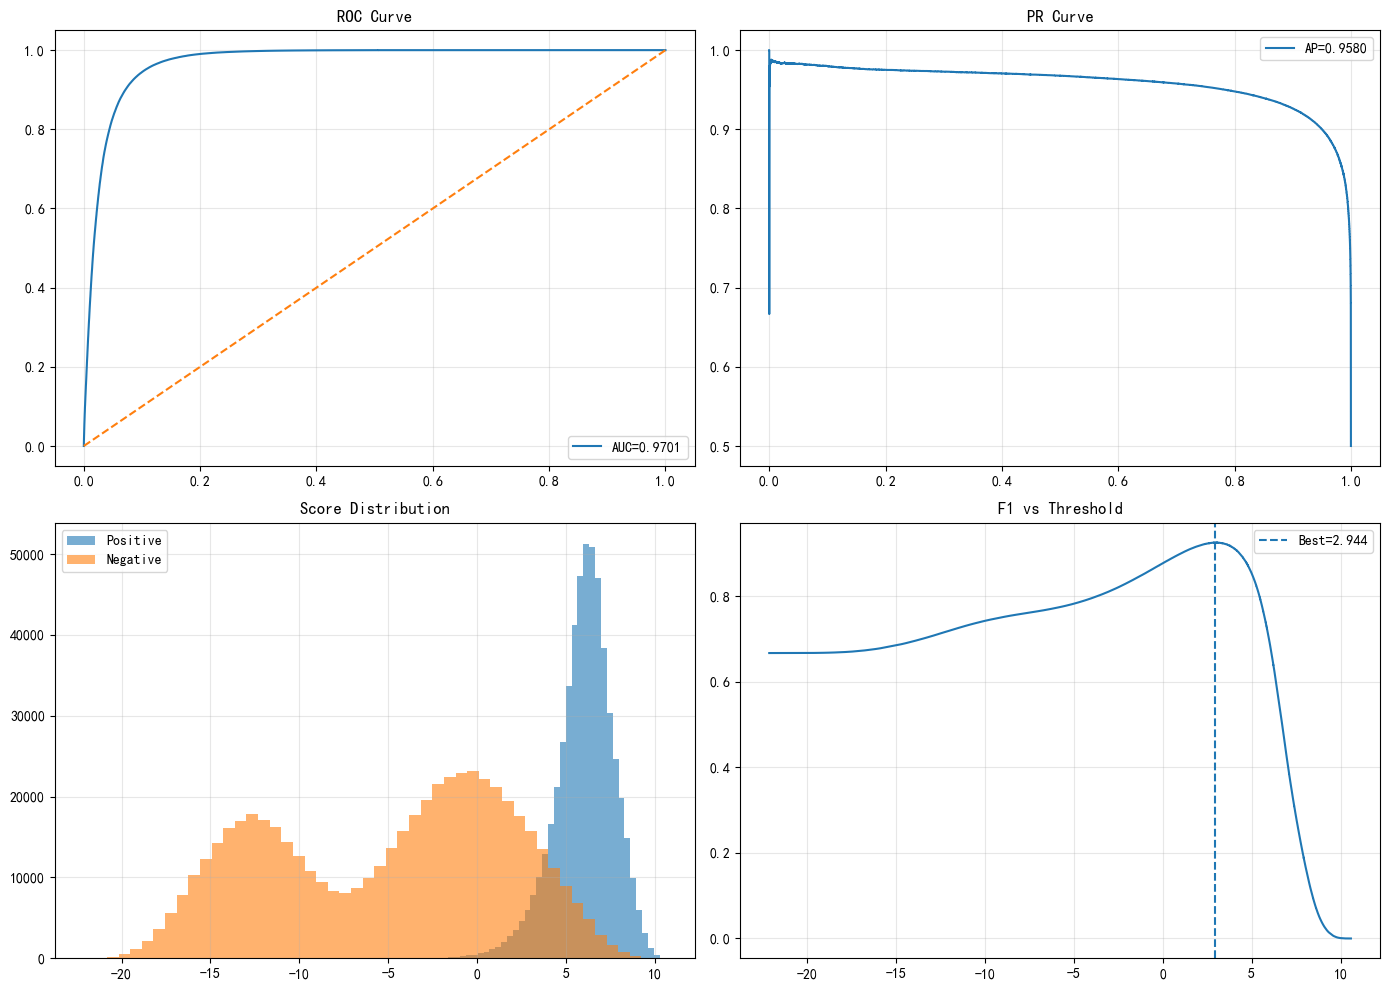


===== Analysis =====
ROC-AUC = 0.9701
PR-AUC  = 0.9580
Best F1 = 0.9246 (threshold=2.9445)


In [48]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score
)

# ============================================================
# 1. 高效评估（decoder-only）
# ============================================================

def evaluate_fast(decoder, z, edges, labels, batch_size=4096):

    decoder.eval()

    # -------- edges --------
    if not isinstance(edges, torch.Tensor):
        edges = torch.tensor(edges, dtype=torch.long)
    else:
        edges = edges.long()

    edges = edges.to(device)

    # -------- labels --------
    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels, dtype=torch.float)
    else:
        labels = labels.float()

    labels = labels.to(device)

    all_scores = []

    with torch.no_grad():

        num_edges = edges.size(0)

        for i in range(0, num_edges, batch_size):

            batch_edges = edges[i:i + batch_size].long()

            scores = decoder(z, batch_edges)

            all_scores.append(scores.detach().cpu().numpy())

    all_scores = np.concatenate(all_scores)
    all_labels = labels.detach().cpu().numpy()

    auc = roc_auc_score(all_labels, all_scores)
    ap = average_precision_score(all_labels, all_scores)

    return auc, ap, all_scores, all_labels


# ============================================================
# 2. 计算 embedding（只做一次）
# ============================================================

print("\n" + "=" * 60)
print("模型性能可视化分析")
print("=" * 60)

best_encoder.eval()
best_decoder.eval()

with torch.no_grad():

    x = data.x.to(device)
    edge_index = data.edge_index.to(device)

    # ⭐ encoder 只跑一次（关键优化）
    z = best_encoder(x, edge_index)


# ============================================================
# 3. 评估
# ============================================================

with torch.no_grad():

    test_auc, test_ap, y_score, y_true = evaluate_fast(
        best_decoder,
        z,
        test_edges,
        test_labels,
        batch_size=4096
    )

y_true = np.array(y_true)
y_score = np.array(y_score)

print(f"Test AUC = {test_auc:.4f}")
print(f"Test AP  = {test_ap:.4f}")


# ============================================================
# 4. ROC
# ============================================================

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)


# ============================================================
# 5. PR
# ============================================================

precision, recall, thresholds = precision_recall_curve(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)


# ============================================================
# 6. Score 分布
# ============================================================

pos_scores = y_score[y_true == 1]
neg_scores = y_score[y_true == 0]


# ============================================================
# 7. ⭐ F1（向量化版本，已修复卡死问题）
# ============================================================

f1_scores = 2 * precision[:-1] * recall[:-1] / (
    precision[:-1] + recall[:-1] + 1e-8
)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("\n===== F1 Analysis =====")
print(f"Best Threshold = {best_threshold:.4f}")
print(f"Best F1        = {best_f1:.4f}")


# ============================================================
# 8. 可视化
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC
axes[0, 0].plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
axes[0, 0].plot([0, 1], [0, 1], "--")
axes[0, 0].set_title("ROC Curve")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# PR
axes[0, 1].plot(recall, precision, label=f"AP={pr_auc:.4f}")
axes[0, 1].set_title("PR Curve")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# score distribution
axes[1, 0].hist(pos_scores, bins=50, alpha=0.6, label="Positive")
axes[1, 0].hist(neg_scores, bins=50, alpha=0.6, label="Negative")
axes[1, 0].set_title("Score Distribution")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# F1 curve
axes[1, 1].plot(thresholds, f1_scores)
axes[1, 1].axvline(best_threshold, linestyle="--",
                   label=f"Best={best_threshold:.3f}")
axes[1, 1].set_title("F1 vs Threshold")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 9. 结论
# ============================================================

print("\n===== Analysis =====")

print(f"ROC-AUC = {roc_auc:.4f}")
print(f"PR-AUC  = {pr_auc:.4f}")
print(f"Best F1 = {best_f1:.4f} (threshold={best_threshold:.4f})")

print("=" * 60)


Cell26：模型深入分析

===== 错误案例分析 =====

Top-5 漏判正样本（真实存在但预测分数最低）：
1. Edge (146939, 120860) | Score = 0.0000
2. Edge (21867, 120860) | Score = 0.0000
3. Edge (52567, 120860) | Score = 0.0000
4. Edge (159913, 120860) | Score = 0.0000
5. Edge (67196, 120860) | Score = 0.0000

Top-5 误判负样本（不存在但预测分数最高）：
1. Edge (127820, 67928) | Score = 0.9999
2. Edge (141706, 137876) | Score = 0.9999
3. Edge (124608, 93053) | Score = 0.9999
4. Edge (18663, 150500) | Score = 0.9999
5. Edge (136575, 62668) | Score = 1.0000

===== 节点度相关性分析 =====
预测分数 vs 节点平均度：r=0.4636, p=4.1568e-107


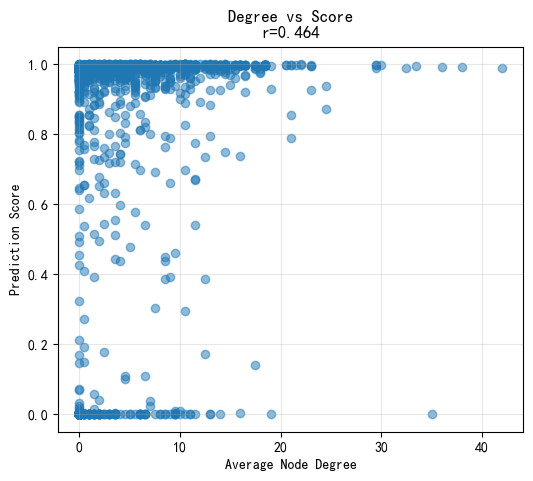


===== 共同邻居相关性分析 =====
预测分数 vs 共同邻居数：r=nan, p=nan


C:\Users\26099\AppData\Local\Temp\ipykernel_11188\2442545118.py:162: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_cn, p_cn = pearsonr(


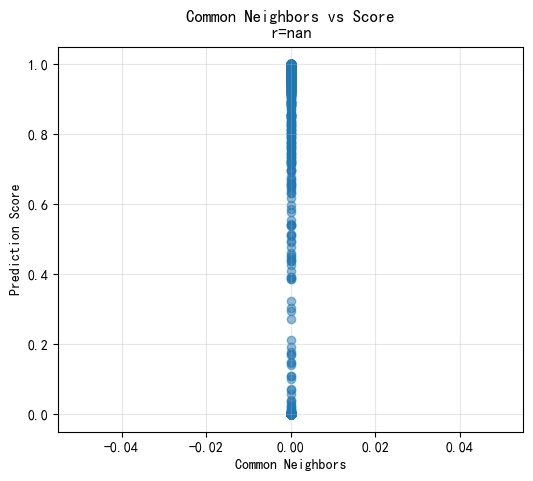


===== t-SNE 可视化 =====
正在执行 t-SNE（约1~2分钟）...


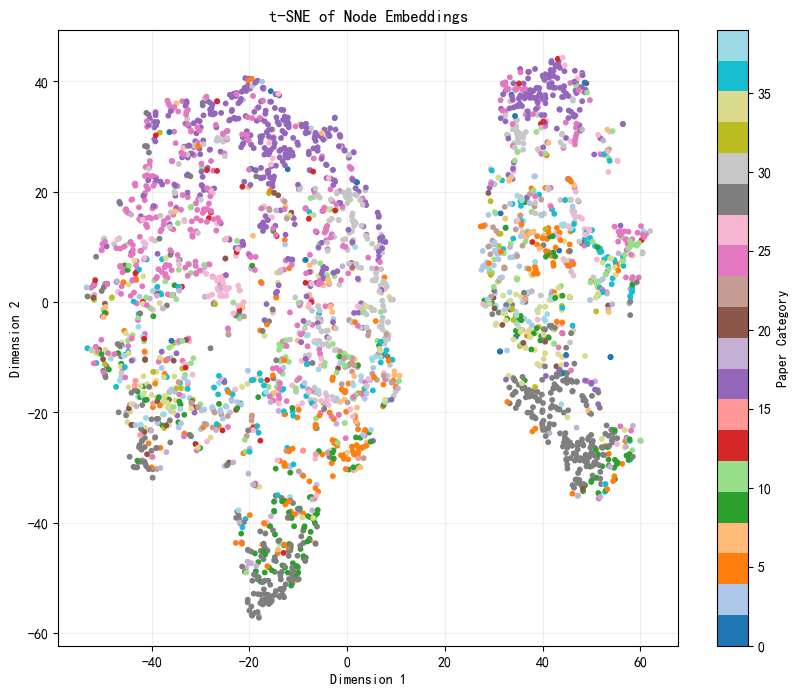


最终实验总结
最佳模型：Hard Negative
测试集性能：AUC=0.8237, AP=0.8382
节点度相关性：r=0.4636
共同邻居相关性：r=nan


In [49]:
# ============================================================
# 错误案例分析 + 相关性分析 + t-SNE + 最终总结
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.stats import pearsonr
from sklearn.metrics import f1_score
from torch_geometric.utils import degree

print("\n" + "="*60)
print("Cell26：模型深入分析")
print("="*60)

# ============================================================
# 1. 获取测试集预测结果
# ============================================================

test_auc, test_ap, y_pred, y_true = evaluate(
    best_encoder,
    best_decoder,
    test_edges,
    test_labels
)

y_pred = np.array(y_pred)
y_true = np.array(y_true)

num_pos = int((y_true == 1).sum())

pos_scores = y_pred[:num_pos]
neg_scores = y_pred[num_pos:]

# ============================================================
# 2. 错误案例分析
# ============================================================

print("\n===== 错误案例分析 =====")

worst_pos_idx = np.argsort(pos_scores)[:5]

print("\nTop-5 漏判正样本（真实存在但预测分数最低）：")

for rank, idx in enumerate(worst_pos_idx, 1):

    src = test_edges[0, idx].item()
    dst = test_edges[1, idx].item()

    print(
        f"{rank}. Edge ({src}, {dst}) "
        f"| Score = {pos_scores[idx]:.4f}"
    )

worst_neg_idx = np.argsort(neg_scores)[-5:]

print("\nTop-5 误判负样本（不存在但预测分数最高）：")

for rank, idx in enumerate(worst_neg_idx, 1):

    real_idx = idx + num_pos

    src = test_edges[0, real_idx].item()
    dst = test_edges[1, real_idx].item()

    print(
        f"{rank}. Edge ({src}, {dst}) "
        f"| Score = {neg_scores[idx]:.4f}"
    )

# ============================================================
# 3. 节点度相关性分析
# ============================================================

print("\n===== 节点度相关性分析 =====")

deg = degree(
    train_graph.edge_index[0],
    num_nodes=data.num_nodes
).cpu().numpy()

pos_src = test_edges[0, :num_pos].cpu().numpy()
pos_dst = test_edges[1, :num_pos].cpu().numpy()

avg_degree = (
    deg[pos_src] +
    deg[pos_dst]
) / 2

sample_size = min(2000, num_pos)

sample_idx = np.random.choice(
    num_pos,
    sample_size,
    replace=False
)

sample_scores = pos_scores[sample_idx]
sample_degree = avg_degree[sample_idx]

corr_deg, p_deg = pearsonr(
    sample_scores,
    sample_degree
)

print(
    f"预测分数 vs 节点平均度："
    f"r={corr_deg:.4f}, p={p_deg:.4e}"
)

# 绘图

plt.figure(figsize=(6,5))

plt.scatter(
    sample_degree,
    sample_scores,
    alpha=0.5
)

plt.xlabel("Average Node Degree")
plt.ylabel("Prediction Score")
plt.title(
    f"Degree vs Score\n"
    f"r={corr_deg:.3f}"
)

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# 4. 共同邻居相关性分析
# ============================================================

print("\n===== 共同邻居相关性分析 =====")

adj = {}

edge_np = train_graph.edge_index.cpu().numpy()

for u, v in edge_np.T:

    adj.setdefault(u, set()).add(v)

cn_scores = []

for idx in sample_idx:

    u = pos_src[idx]
    v = pos_dst[idx]

    neigh_u = adj.get(u, set())
    neigh_v = adj.get(v, set())

    cn_scores.append(
        len(neigh_u & neigh_v)
    )

cn_scores = np.array(cn_scores)

corr_cn, p_cn = pearsonr(
    sample_scores,
    cn_scores
)

print(
    f"预测分数 vs 共同邻居数："
    f"r={corr_cn:.4f}, p={p_cn:.4e}"
)

plt.figure(figsize=(6,5))

plt.scatter(
    cn_scores,
    sample_scores,
    alpha=0.5
)

plt.xlabel("Common Neighbors")
plt.ylabel("Prediction Score")

plt.title(
    f"Common Neighbors vs Score\n"
    f"r={corr_cn:.3f}"
)

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# 5. t-SNE 节点嵌入可视化
# ============================================================

print("\n===== t-SNE 可视化 =====")

best_encoder.eval()

with torch.no_grad():

    z = best_encoder(
        data.x.to(device),
        train_graph.edge_index.to(device)
    )

z = z.cpu().numpy()

num_sample = min(3000, data.num_nodes)

sample_nodes = np.random.choice(
    data.num_nodes,
    num_sample,
    replace=False
)

embeddings = z[sample_nodes]

labels = data.y[sample_nodes].cpu().numpy()

if labels.ndim > 1:
    labels = labels.squeeze()

print("正在执行 t-SNE（约1~2分钟）...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

emb_2d = tsne.fit_transform(
    embeddings
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    emb_2d[:,0],
    emb_2d[:,1],
    c=labels,
    cmap='tab20',
    s=10
)

plt.colorbar(
    scatter,
    label="Paper Category"
)

plt.title(
    "t-SNE of Node Embeddings"
)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.grid(alpha=0.2)

plt.show()

# ============================================================
# 6. 最终总结
# ============================================================

print("\n" + "="*60)
print("最终实验总结")
print("="*60)

print(f"最佳模型：{best_name}")

print(
    f"测试集性能："
    f"AUC={test_auc:.4f}, "
    f"AP={test_ap:.4f}"
)

print(
    f"节点度相关性："
    f"r={corr_deg:.4f}"
)

print(
    f"共同邻居相关性："
    f"r={corr_cn:.4f}"
)

In [50]:
# ============================================================
# 最终训练脚本：GraphSAGE vs GAT
# 使用统一的 decoder 接口（MLPDecoder 示例）
# ============================================================

print("\n" + "="*60)
print("开始训练: 对比 GraphSAGE 与 GAT")
print("="*60)

# 这里假设你的 GraphSAGEEncoder / GATEncoder 已定义
# 并且 data, all_pos_edges, train_pos, val_edges, val_labels,
# test_edges, test_labels, train_loader 已准备好

model_configs = [
    {
        'name': 'GraphSAGE',
        'encoder_class': GraphSAGEEncoder,
        'encoder_kwargs': {
            'in_channels': data.x.size(1),
            'hidden_channels': 128,
            'out_channels': 64,
            'dropout': 0.5
        },
        'train_kwargs': {
            'batch_size': 128,
            'accumulation_steps': 4,
            'num_neighbors': [10, 10],
            'use_hard_negative': True,
            'hard_ratio': 2,
            'max_candidates': 30000,
            'chunk_size': 10000
        }
    },
    {
        'name': 'GAT',
        'encoder_class': GATEncoder,
        'encoder_kwargs': {
            'in_channels': data.x.size(1),
            'hidden_channels': 16,          # 大幅降低显存
            'out_channels': 64,
            'heads': 4,
            'dropout': 0.4
        },
        'train_kwargs': {
            'batch_size': 64,
            'accumulation_steps': 8,
            'num_neighbors': [5, 5],
            'use_hard_negative': False,     # GAT 关闭硬负采样
            'hard_ratio': 2,
            'max_candidates': 30000,
            'chunk_size': 10000
        }
    }
]

results = {}

for config in model_configs:
    print(f"\n{'='*50}")
    print(f"正在训练模型: {config['name']}")
    print('='*50)

    encoder = config['encoder_class'](**config['encoder_kwargs']).to(device)
    # 你可以自由替换为 InnerProductDecoder 或 CosineDecoder
    decoder = MLPDecoder(64, 128).to(device)

    encoder, decoder, best_val_ap, history, best_state = train_link_model(
        encoder=encoder,
        decoder=decoder,
        train_loader=train_loader,       # 初始 loader（内部会重建）
        val_edges=val_edges,
        val_labels=val_labels,
        data=data,
        all_pos_edges=all_pos_edges,
        train_pos=train_pos,
        num_nodes=data.num_nodes,
        epochs=100,
        lr=0.001,
        weight_decay=5e-4,
        patience=20,
        eval_interval=5,
        **config['train_kwargs']
    )

    if best_state is not None:
        torch.save(best_state['encoder'], f"{config['name']}_best_encoder.pt")
        torch.save(best_state['decoder'], f"{config['name']}_best_decoder.pt")
        print(f"✅ 最佳模型已保存为 {config['name']}_best_encoder.pt 和 {config['name']}_best_decoder.pt")
    else:
        print(f"⚠️  {config['name']} 未获得有效最佳模型，跳过保存")

    test_auc, test_ap, _, _ = evaluate(encoder, decoder, test_edges, test_labels)
    results[config['name']] = {'AUC': test_auc, 'AP': test_ap}
    print(f"\n✅ {config['name']} 测试结果: AUC={test_auc:.4f}, AP={test_ap:.4f}")

print("\n" + "="*60)
print("最终对比结果（真实性能，无泄漏）")
print("="*60)
for name, metrics in results.items():
    print(f"{name:12s} | AUC: {metrics['AUC']:.4f} | AP: {metrics['AP']:.4f}")


开始训练: 对比 GraphSAGE 与 GAT

正在训练模型: GraphSAGE
✅ 初始训练集：正边 378578，负边 378578
Epoch 001 started at 23:50:23
Epoch 001 finished in 63.80s, Loss: 0.2424
Epoch 002 started at 23:51:27
Epoch 002 finished in 62.38s, Loss: 0.1763
Epoch 003 started at 23:52:29
Epoch 003 finished in 60.53s, Loss: 0.1608
Epoch 004 started at 23:53:30
Epoch 004 finished in 59.88s, Loss: 0.1549
Epoch 005 started at 23:54:30
Epoch 005 finished in 59.46s, Loss: 0.1524
Epoch 005 | Loss: 0.1524 | Val AUC: 0.8959 AP: 0.9011
Epoch 006 started at 23:55:30
Epoch 006 finished in 59.03s, Loss: 0.1503
Epoch 007 started at 23:56:29
Epoch 007 finished in 61.36s, Loss: 0.1479
Epoch 008 started at 23:57:30
Epoch 008 finished in 64.12s, Loss: 0.1474
Epoch 009 started at 23:58:34
Epoch 009 finished in 65.10s, Loss: 0.1462
Epoch 010 started at 23:59:39
  🔄 更新硬负样本...
Epoch 010 finished in 40.14s, Loss: 0.0571
Epoch 010 | Loss: 0.0571 | Val AUC: 0.8868 AP: 0.8913
Epoch 011 started at 00:00:20
Epoch 011 finished in 39.61s, Loss: 0.0580
Ep

In [56]:
import re
import matplotlib.pyplot as plt

# ==============================
# 读取日志文件
# ==============================
log_file = "link_prediction_log.txt"  

with open(log_file, "r", encoding="utf-8") as f:
    log_text = f.read()

# ==============================
# 初始化
# ==============================
results = {
    "GraphSAGE": {
        "loss": [],
        "val_epoch": [],
        "val_auc": [],
        "val_ap": [],
        "test_auc": None,
        "test_ap": None
    },
    "GAT": {
        "loss": [],
        "val_epoch": [],
        "val_auc": [],
        "val_ap": [],
        "test_auc": None,
        "test_ap": None
    }
}

current_model = None

# ==============================
# 逐行解析日志
# ==============================
for line in log_text.splitlines():

    line = line.strip()

    # 模型切换
    if "正在训练模型: GraphSAGE" in line:
        current_model = "GraphSAGE"
        continue

    if "正在训练模型: GAT" in line:
        current_model = "GAT"
        continue

    if current_model is None:
        continue

    # ----------------------------------
    # 提取 Loss
    # Epoch xxx finished ..., Loss: xxx
    # ----------------------------------
    m = re.search(
        r"Epoch\s+(\d+)\s+finished.*Loss:\s*([\d\.]+)",
        line
    )

    if m:
        loss = float(m.group(2))
        results[current_model]["loss"].append(loss)

    # ----------------------------------
    # 提取验证AUC/AP
    # Epoch xxx | Loss: xxx | Val AUC: xxx AP: xxx
    # ----------------------------------
    m = re.search(
        r"Epoch\s+(\d+)\s+\|\s+Loss:.*Val AUC:\s*([\d\.]+)\s+AP:\s*([\d\.]+)",
        line
    )

    if m:
        epoch = int(m.group(1))
        auc = float(m.group(2))
        ap = float(m.group(3))

        results[current_model]["val_epoch"].append(epoch)
        results[current_model]["val_auc"].append(auc)
        results[current_model]["val_ap"].append(ap)

    # ----------------------------------
    # 提取测试结果
    # ----------------------------------
    m = re.search(
        r"测试结果:\s*AUC=([\d\.]+),\s*AP=([\d\.]+)",
        line
    )

    if m:
        results[current_model]["test_auc"] = float(m.group(1))
        results[current_model]["test_ap"] = float(m.group(2))


# ==============================
# 打印结果检查
# ==============================
for model in results:
    print("="*50)
    print(model)

    print("Loss数量：", len(results[model]["loss"]))

    print("Val数量：", len(results[model]["val_auc"]))

    print(
        f"Test AUC={results[model]['test_auc']}, "
        f"Test AP={results[model]['test_ap']}"
    )

GraphSAGE
Loss数量： 100
Val数量： 20
Test AUC=0.8124, Test AP=0.8282
GAT
Loss数量： 100
Val数量： 20
Test AUC=0.9038, Test AP=0.8945


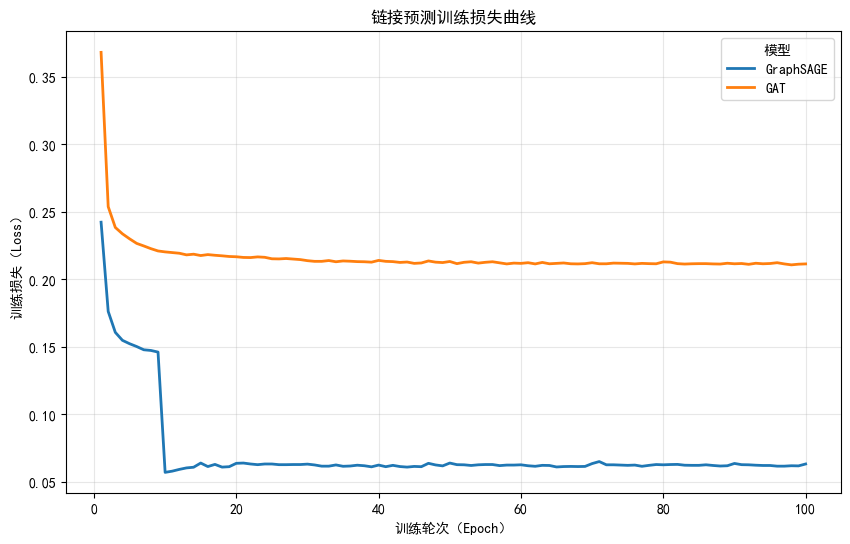

In [57]:
plt.figure(figsize=(10,6))

for model in results:
    epochs = range(1, len(results[model]["loss"]) + 1)

    label = "GraphSAGE" if model == "GraphSAGE" else "GAT"

    plt.plot(
        epochs,
        results[model]["loss"],
        linewidth=2,
        label=label
    )

plt.xlabel("训练轮次（Epoch）")
plt.ylabel("训练损失（Loss）")
plt.title("链接预测训练损失曲线")

plt.legend(title="模型")
plt.grid(alpha=0.3)

plt.show()

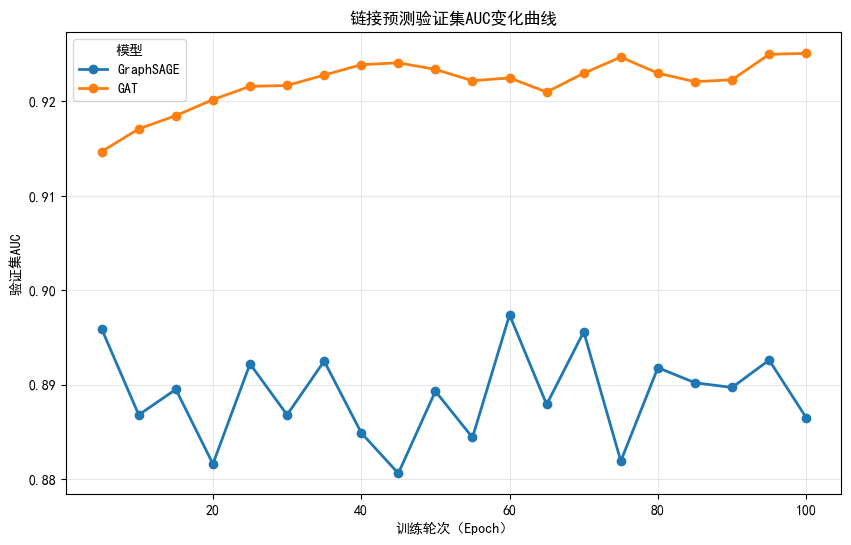

In [58]:
plt.figure(figsize=(10,6))

for model in results:

    label = "GraphSAGE" if model == "GraphSAGE" else "GAT"

    plt.plot(
        results[model]["val_epoch"],
        results[model]["val_auc"],
        marker='o',
        linewidth=2,
        label=label
    )

plt.xlabel("训练轮次（Epoch）")
plt.ylabel("验证集AUC")
plt.title("链接预测验证集AUC变化曲线")

plt.legend(title="模型")
plt.grid(alpha=0.3)

plt.show()

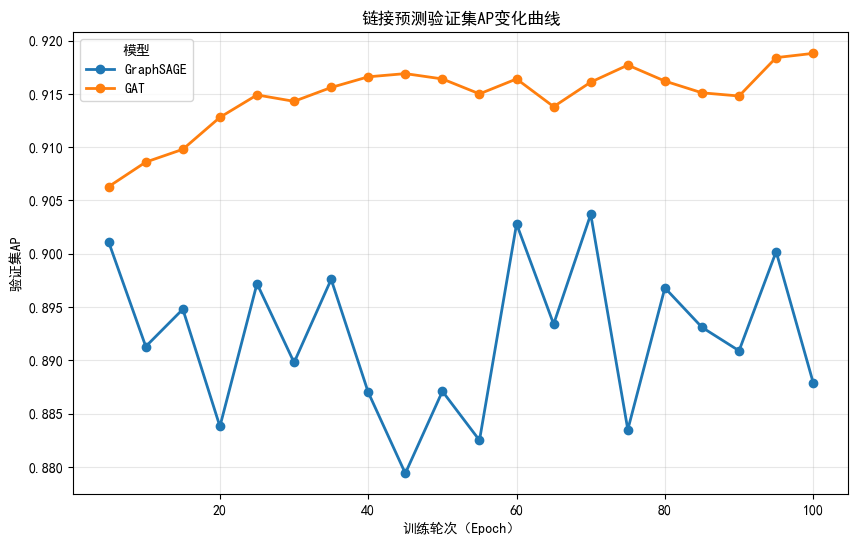

In [59]:
plt.figure(figsize=(10,6))

for model in results:

    label = "GraphSAGE" if model == "GraphSAGE" else "GAT"

    plt.plot(
        results[model]["val_epoch"],
        results[model]["val_ap"],
        marker='o',
        linewidth=2,
        label=label
    )

plt.xlabel("训练轮次（Epoch）")
plt.ylabel("验证集AP")
plt.title("链接预测验证集AP变化曲线")

plt.legend(title="模型")
plt.grid(alpha=0.3)

plt.show()

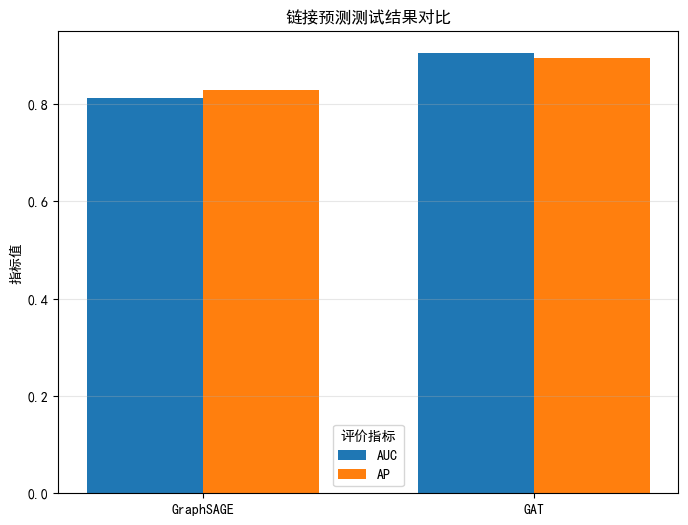

In [60]:
models = ["GraphSAGE", "GAT"]

test_auc = [
    results["GraphSAGE"]["test_auc"],
    results["GAT"]["test_auc"]
]

test_ap = [
    results["GraphSAGE"]["test_ap"],
    results["GAT"]["test_ap"]
]

x = range(len(models))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(
    [i - width/2 for i in x],
    test_auc,
    width=width,
    label="AUC"
)

plt.bar(
    [i + width/2 for i in x],
    test_ap,
    width=width,
    label="AP"
)

plt.xticks(x, models)

plt.ylabel("指标值")
plt.title("链接预测测试结果对比")

plt.legend(title="评价指标")
plt.grid(axis='y', alpha=0.3)

plt.show()


生成 GraphSAGE ROC 曲线...


C:\Users\26099\AppData\Local\Temp\ipykernel_11188\2188815135.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(
C:\Users\26099\AppData\Local\Temp\ipykernel_111


生成 GAT ROC 曲线...


C:\Users\26099\AppData\Local\Temp\ipykernel_11188\2188815135.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(
C:\Users\26099\AppData\Local\Temp\ipykernel_111

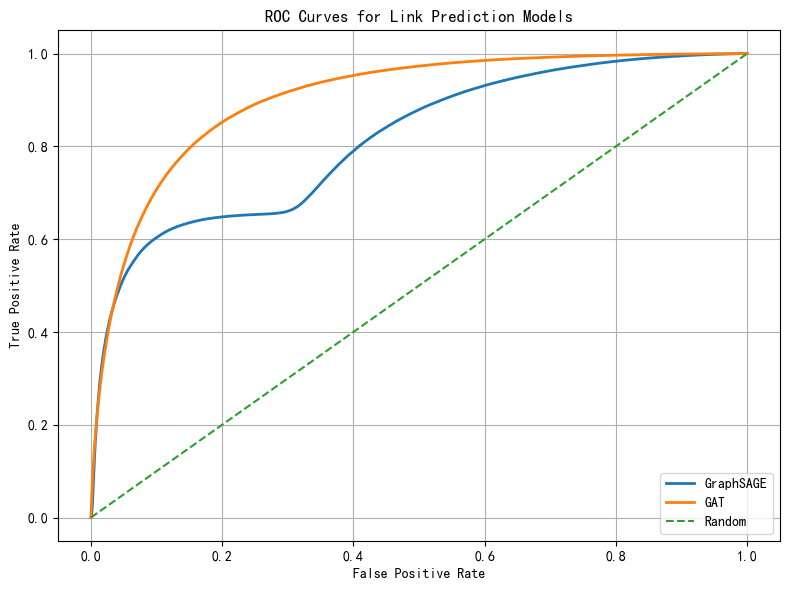


ROC 图已保存：roc_comparison.png


In [71]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import torch

roc_device = torch.device("cpu")

plt.figure(figsize=(8,6))

roc_results = {}

model_configs = [
    {
        'name': 'GraphSAGE',
        'encoder_class': GraphSAGEEncoder,
        'encoder_kwargs': {
            'in_channels': data.x.size(1),
            'hidden_channels': 128,
            'out_channels': 64,
            'dropout': 0.5
        }
    },
    {
        'name': 'GAT',
        'encoder_class': GATEncoder,
        'encoder_kwargs': {
            'in_channels': data.x.size(1),
            'hidden_channels': 16,
            'out_channels': 64,
            'heads': 4,
            'dropout': 0.4
        }
    }
]

for config in model_configs:

    name = config['name']
    print(f"\n生成 {name} ROC 曲线...")

    # Encoder
    encoder = config['encoder_class'](
        **config['encoder_kwargs']
    ).to(roc_device)

    encoder.load_state_dict(
        torch.load(
            f"{name}_best_encoder.pt",
            map_location=roc_device
        )
    )

    # Decoder
    decoder = MLPDecoder(
        in_channels=64,
        hidden_channels=128
    ).to(roc_device)

    decoder.load_state_dict(
        torch.load(
            f"{name}_best_decoder.pt",
            map_location=roc_device
        )
    )

    encoder.eval()
    decoder.eval()

    # ===== 与 evaluate() 完全一致 =====
    with torch.no_grad():

        z = encoder(
            data.x.cpu(),
            train_graph.edge_index.cpu()   # 关键修复！
        )

        batch_size = 4096
        all_preds = []

        num_edges = test_edges.size(1)

        for start in range(0, num_edges, batch_size):

            end = min(start + batch_size, num_edges)

            edge_batch = test_edges[:, start:end].cpu()

            pred_batch = torch.sigmoid(
                decoder(z, edge_batch)
            )

            all_preds.append(
                pred_batch.numpy()
            )

        y_score = np.concatenate(all_preds)

    y_true = test_labels.numpy()

    fpr, tpr, _ = roc_curve(
        y_true,
        y_score
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name}"
    )

    roc_results[name] = (
        fpr,
        tpr
    )

# 随机分类器
plt.plot(
    [0,1],
    [0,1],
    '--',
    linewidth=1.5,
    label='Random'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves for Link Prediction Models")

plt.legend(loc='lower right')

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "roc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nROC 图已保存：roc_comparison.png")